# Noise and errors

This lesson will introduce quantum noise and errors, including many of their sources, and drawing analogies with classical errors. Understanding the types of errors that may occur, and the ability to model noise using quantum channels, will be critical to understanding future lessons. Indeed, most methods of error handling require that we know something about the type of noise or errors we seek to reduce or correct.

A video to accompany this lesson will launch in the next few days, and will be embedded here.

## Causes

### Classical noise and errors

To understand quantum errors and noise, let’s start with the classical analog. Errors occur in classical computers for a variety of reasons, including multiple mechanisms for spurious charge accumulation, single-event upsets, and slow material degradation. Some of these mechanisms (not all) have analogs in quantum computing and will be instrumental in understanding quantum errors and noise. We briefly review a few of those and then move on to the quantum analogs.

__Thermal noise:__

As components of a computer heat up, the thermal motion of the atoms and charge carriers changes the resistivity of the material (usually increasing it). This means the resistance in the circuit can vary. Although rare, this can result in spurious logic transition in a transistor. Although minor variations are inescapable, proper cooling of components is key in avoiding these effects.

__Thermal damage and degradation:__

Repeated heating and cooling of materials can cause very slow migration of conductive elements (metals). At best, this changes the resistance and/or capacitance of circuit elements and leads to imprecise timing in circuit operation. At worst, it results in a short-circuit and/or hard fault. Again, proper temperature control is key in preventing this type of degradation.

__Radiation-induced effects (single-event upsets, SEUs):__

Sometimes, high-energy particles can ionize atoms inside a processor and lead to a spurious charge. If it happens at the wrong place and wrong time, this can lead to logical errors. The source of these high-energy particles (including electromagnetic radiation and neutrons) is typically high-energy interactions in the upper atmosphere. These upsets are thus more common in high-altitude environments, including space. These are addressed using error-correcting codes and radiation-hard design.

__Electromagnetic interference:__

Errors can also be caused by external electromagnetic fields from switching power lines, radio transmitters, or other system components. This is different from the high-energy radiation in the previous phenomenon. Here, stray time-dependent EM fields induce current and voltage across computing components (as opposed to ionizing a particular atom in one event). Because the time-dependence of fields is a determining factor in the induced voltages, this type of interference is especially important in high-frequency systems. These errors can be combatted through shielding and grounding among other things.

__Crosstalk between interconnects:__

Capacitive or inductive coupling between adjacent conductors, especially in nanoscale integrated circuits, can lead to spurious signals. This is related to electromagnetic interference, but it is different because the source of the offending field is another component inside the computer circuit. Think of two wires very close to each other. If wire A experiences a sudden transition (change in voltage) it can induce currents in the adjacent wire B. The exact direction and magnitude depend on circuit layout; it could be a coherent net flow of charge or something closer to eddy currents of charge. But in some cases this can lead to unwanted logical transitions. These cross-talk effects can be mitigated through optimal layout spacing, shielding, and controlled signal rise times.

This is not a complete list, but it is sufficient for us to begin to see parallels with quantum computing. Note that in all the types of unwanted interactions above, the manifestation of the noise as a logical error can only take the form of a 0 becoming a 1, or a 1 becoming a 0. This is all that is permitted in the state space of classical bits.

### Quantum noise and errors:

In quantum computing, noise and errors are often discussed hand-in-hand, but it is important to recognize the difference. Quantum noise refers to the underlying physical disturbance affecting qubits and quantum systems. It includes all forms of unwanted interactions or fluctuations from the environment, imperfect controls, or hardware defects that cause the quantum state to drift away from the ideal. Quantum errors are the specific deviations or faults in the quantum information that result from the quantum noise. Quantum errors are the measurable or operational manifestations of the noise, and errors include bit-flips, phase-flips, amplitude damping and more.
Both noise and errors can occur in a continuous way. For example, the field used in a quantum gate could be off by 0.1%, 0.15% or any other fraction. This could result in a phase on a qubit that is incorrect, also by any continuous amount. But you will see that, in practice and especially in error-correction, it is common to see errors treated as though they are discrete: grouping the accumulated effects into a discrete bit flip or a single phase rotation. This is useful for correcting errors, and characterizing them, but it does not mean that the effects of noise on a qubit is solely a discrete set of errors.

There are many types of noise that affect quantum computers. Some can result in multiple types of errors, while others are paired with specific error manifestations. A complete list is beyond the purposes of this lesson; here is a partial list relevant to the rest of this course, some with parallels to classical computing noise.

__Thermal:__

The two computational basis states $|0\rangle$ and $|1\rangle$ of a qubit are separated by a very small amount of energy. The exact value depends, of course, on the quantum hardware. For solid-state (fixed frequency transmon) qubits such as those used by IBM Quantum, the energy gap between these states is on the order of $10^{-24}$ J, or a few micro electron volts. This energy scale can be related to the frequency via $E=hf$ or to a characteristic temperature. Since temperature is the average kinetic energy of particles in a sample, it is useful to relate this energy to temperature using the Boltzmann constant to obtain an estimate of the temperature at which average particles would have enough energy to cause a transition:

$$
E\approx k_BT \rightarrow T~E/k_B \approx 10^{-24}\text{ J } \times 1.381 \times 10^{−23}\text{ J/K}\approx 100 \text{mK}.
$$

So in order for it to be very rare that thermal interactions cause transitions from one qubit computational basis state to another, the temperature of the qubits must be maintained substantially below 100 mK, ideally closer to 15-25 mK. Any significant increase in temperature above these thresholds would result in totally random state occupation and total loss of quantum information.

This is analogous to the thermal errors that can occur in classical computers insomuch as they are both thermal in origin. But the temperature scale is obviously different and so is the mechanism for information loss.

__Crosstalk and interference:__

Crosstalk in quantum computing refers to any unwanted coupling or interference between qubits or control lines such that an operation or signal intended for one qubit inadvertently affects others. It manifests as errors or correlations between qubits that should ideally be independent.

In superconducting qubit architectures like those used by IBM, crosstalk may arise from microwave control signals leaking into neighboring qubits, unintended coupling between readout resonators, or flux crosstalk between qubit loops.

Many of the approaches to minimizing crosstalk are incorporated into the design of a quantum computer, such as spacing of qubits and ensuring adjacent qubits have different operational frequencies. There are also software approaches to mitigating crosstalk errors, which will be discussed in later lessons.

__Imperfect gate operations:__

Operations on qubits are carried out using hardware that has finite precision and which may be subject to noise or other sources of inaccuracy. In particular, microwave pulses of specific durations and with specific orientations are used to implement rotation gates. Say for example that a microwave pulse is to rotate 0.30 radians around the $X$ axis. There is finite precision in the orientation, leading to some imprecision in the axis of rotation. Further, there is always a fundamental tradeoff between a pulse frequency and its duration. A very long pulse can have essentially a sinusoidal behavior with practically a single frequency. To form a short packet, one needs a superposition of many frequencies. This is the same tradeoff at the root of the energy-time uncertainty relation, although gate precision is not yet pushing up against these fundamental limits; there is room for improvement.

__Quantum-inherent noise:__

This last type of noise is quite different from the others; it is not due to errors, but due to the nature of quantum mechanics. Suppose a qubit in quantum state $|\psi\rangle$ is measured and collapses to an eigenstate ($|0\rangle$ or $|1\rangle$). In a fixed-frequency transmon system, the qubit is dispersively coupled to a microwave resonator whose resonance frequency depends slightly on the qubit state. A microwave probe pulse is sent through the resonator, and the outgoing signal acquires a state-dependent phase shift and amplitude change. This signal is then amplified and measured using classical electronics.

At the quantum level, the measurement signal is carried by a coherent microwave field with a finite average number of photons. Due to the quantum nature of electromagnetic fields, the field quadratures exhibit intrinsic fluctuations. These fluctuations are independent of technical imperfections and arise even for an ideal coherent state. Increasing the average photon number $N$ increases the measurement signal, but the fundamental noise level remains finite, so that the distinguishability between outcomes improves only as $\sqrt{N}$​.

Thus, even if the qubit is perfectly prepared and the measurement chain is ideal, the readout signal corresponding to a given qubit state is not a single fixed value but a distribution that limits how well the outcomes can be distinguished. This overlap represents a fundamental source of uncertainty in the measurement process itself. In practice, while technical noise from amplifiers and other components often dominates, this intrinsic quantum noise sets a lower bound on readout fidelity.

__Uncertainty is not error:__

These sources of noise are all different from the fundamental uncertainty associated with measurements of quantum states. For contrast, suppose that we have a qubit in a quantum state:

$$|\psi\rangle = \frac{4}{5}|0\rangle+\frac{3}{5}|1\rangle.$$

This state has a 64% chance of being measured in the $|0\rangle$ state and a 36% chance of being measured in the $|1\rangle$ state. But a single measurement will only yield a $|0\rangle$ or a $|1\rangle.$ So a single measurement will rarely tell us much about the state prior to measurement. Many measurements are required to obtain detailed information about the state. Out of ten measurements, we might expect 6 or 7 to yield $|0\rangle.$ But it would not be shocking if the first ten measurements all happened to yield $|0\rangle$ (like flipping a fair coin and obtaining "heads" ten times in a row: uncommon, but entirely plausible). If we repeated the measurement 1000 times and always obtained $|0\rangle,$ now that would be shocking. So there is uncertainty in our knowledge of the quantum state based on any finite number of measurements. As we repeat the measurements, our knowledge of the quantum state prior to measurement improves, but it is never perfect. One might colloquially say that there is thus always some underlying “error” in any quantum measurement result. But this is a different use of the term “error” and this is better described as statistical uncertainty. The process of increasing knowledge of a quantum state via many measurements is called quantum state tomography. Quantum state tomography is not limited to measurements along Z, however; it generally refers to measurements along orthogonal axes (like X, Y, and Z) for determination of amplitudes and relative phase. For more on this process, see [this section]( https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information/general-measurements/discrimination-and-tomography) in John Watrous’s course on the [General Formulation of Quantum Information]( https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information), or for a practical implementation, see [this teleportation lesson]( https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/teleportation) of the course on [Utility-Scale Quantum Computing]( https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing).


## Observing errors and their accumulation

In this section, we will use real quantum computers to observe quantum errors and their accumulation under different conditions. In practice, many sources of quantum errors are typically present simultaneously. In order to observe different types of errors in a somewhat isolated way, we will need to use circuits designed for that isolation. Circuits used in applications of quantum computing will look much more complicated.

Let's start with energy relaxation errors.

### Energy relaxation ($T_1$) errors

Recall from our discussion of thermal noise that at any non-zero temperature, there is some probability of a quantum system undergoing a transition between energy eigenstates. The relaxation ($|1\rangle> \rightarrow |0\rangle$) dominates because it's driven by spontaneous emission (independent of temperature), while low temperature suppresses the competing excitation process. The longer a qubit sits idle, the more time it has to undergo such a transition. The probability that qubit prepared in the state $|1\rangle$ remains in $|1\rangle$ after a time $t$ is given by

$$
p = e^{-t/T_1}
$$

Here, the time $T_1$ is an experimentally-determined characteristic time that is different for every qubit, and may even change slightly over time. IBM Quantum computers are benchmarked regularly, so the $T_1$ times that you find listed for qubits on IBM Quantum computers should be accurate and up-to-date. A large value of $T_1$ means the qubit remains in the state you prepared longer (on average). Typical $T_1$ values differ across architectures; the qubits in IBM quantum computers often have $T_1$ times on the order of 200-300 $\mu s$. But the latest values can be checked [here](https://quantum.cloud.ibm.com/computers).

The characteristic time $T_2$ measures something different: the loss of phase information. We will return to this later.

To observe energy relaxation errors, we will prepare qubits in the $|1\rangle$ state, and then intentionally leave them idle for long periods of time. This is the artificial part. In real quantum workflows, you might have a few qubits that sit idle for long periods while processes are carried out on other qubits; so a few instances of such idle times is *not* artificial.

Let's begin by importing some packages and selecting the least busy backend.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt

# If your credentials are already saved locally
service = QiskitRuntimeService()

# To load an unsaved instance, uncomment the line below
# service = QiskitRuntimeService(channel = "ibm_quantum_platform", instance = "your crn here")

# To select the least busy backend:
# backend = service.least_busy(simulator=False, operational=True)

# To specify the backend by name:
backend = service.backend("ibm_boston")

props = backend.properties()
print(backend)

<IBMBackend('ibm_boston')>


Now we will select a qubit to work on, in this case, qubit zero. We can directly import the properties of this qubit, including $T_1$ and $T_2$.

In [2]:
qubit_idx = 0
qubit_props = props.qubit_property(qubit_idx)

t1 = qubit_props["T1"][0]  # * 1e6  # Convert seconds to µs
t2 = qubit_props["T2"][0]  # * 1e6  # Convert seconds to µs

# print(f"Qubit {qubit_idx}: T1={t1} µs, T2={t2} µs")
print(f"Qubit {qubit_idx}: T1={t1} s, T2={t2} s")

Qubit 0: T1=0.0002737016180018049 s, T2=0.00042784777605680494 s


Knowing $T_1$ in units of microseconds is important, but you may not have an intuitive feel for what that means. After all, gate operations on quantum computers are very fast. The real question is: how much can I do on a quantum computer in that amount of time. To this end, it is useful to relate $T_1$ to other time scales used in quantum computing. Specifically to the

* sampling time $dt$ - the smallest clock tick over which control processes can be implemented on the quantum computer.
* single-qubit gate times - the time required to implement a gate operation on a single qubit. This will not be a single value, but a range of possible numbers depending on gate type.
* two-qubit gate times - the time required to implement a gate operation on two adjacent qubits. This may also take on a range of values, but is typically about one order of magnitude longer than for a single qubit gate.

Let's check dt for our backend, and display some plausible ranges for gate times.

In [3]:
print(f"Using backend: {backend.name}")

# Access the backend target
target = backend.target


def get_gate_times(target, gate_name):
    results = []

    if gate_name not in target:
        return results  # gate not supported

    # target[gate_name] is a dict: {(qubits): InstructionProperties}
    for qubits, props in target[gate_name].items():
        if props.duration is not None:
            results.append({"qubits": qubits, "duration_ns": props.duration * 1e9})

    return results


# Query some gates
for gate in ["cz", "x"]:
    times = get_gate_times(target, gate)

    print(f"\nGate: {gate}")
    if times:
        for entry in times[:5]:
            print(f"  Qubits {entry['qubits']}: {entry['duration_ns']:.2f} ns")
    else:
        print("  Not available on this backend")

Using backend: ibm_boston

Gate: cz
  Qubits (0, 1): 68.00 ns
  Qubits (1, 0): 68.00 ns
  Qubits (1, 2): 68.00 ns
  Qubits (2, 1): 68.00 ns
  Qubits (2, 3): 88.00 ns

Gate: x
  Qubits (0,): 32.00 ns
  Qubits (1,): 32.00 ns
  Qubits (2,): 32.00 ns
  Qubits (3,): 32.00 ns
  Qubits (4,): 32.00 ns


These gate times will vary from backend to backend. We will hard-code a two-qubit gate time pulled from `ibm_boston` of 68 ns.

In [4]:
dt = backend.configuration().dt
two_q_gate_time = 68e-9
print("The sampling time is : ", dt)
print("dts per T_1 : ", t1 / dt)
print("2-qubit characteristic time : ", two_q_gate_time)
print("The sampling time intervals per two-qubit gate : ", two_q_gate_time / dt)
print("2-qubit gates per T_1 : ", t1 / two_q_gate_time)

The sampling time is :  4e-09
dts per T_1 :  68425.40450045122
2-qubit characteristic time :  6.8e-08
The sampling time intervals per two-qubit gate :  17.0
2-qubit gates per T_1 :  4025.0237941441897


Keep in mind that no other error sources nor their suppression or mitigation have been taken into account here. $T_1$ errors are not the only errors at work in a quantum system. So don't read too much into these numbers. This simply means, in the absence of any suppression, one might plausibly implement on the order of thousands of two-qubit gates before $T_1$ errors start to dominate. Other errors will typically dominate at much lower depths, and conversely $T_1$ errors may still be worth suppressing at much shorter times than those required to wash out the signal entirely.

We will start by using a simulator with a noise model, and then we will compare the results to real hardware.

In [5]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer.primitives import EstimatorV2

pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=0)

Let us define a time step for our measurements corresponding to the high end estimate for a two-qubit gate time. Then we will build 50 circuits in increments of that time step. This way we will see what happens over a time scale similar to implementing 80 two-qubit gates. Precision here is not critical, so we will use only a handful of shots.

In [6]:
n_points = 50  # We will show 50 steps
delay_unit = 80  # The delay in units of two-qubit-time from above
shots = 100

We build a noise model for our simulator that explicitly includes thermal relaxation errors.

In [7]:
# Create noise model with thermal relaxation for delays
noise_model = NoiseModel()
error = thermal_relaxation_error(
    t1, t2, two_q_gate_time * delay_unit
)  # error model characterized by times in ns
noise_model.add_all_qubit_quantum_error(error, ["delay"])

sim = AerSimulator(noise_model=noise_model)

Now we build our circuits and observables. These are exceptionally simple. The circuits will consist simply of preparing the qubit in $|1\rangle$ and implementing delays for increasing periods of time, using the characteristic gate times and $dt$ defined above. The observables will simply be $Z$, since what we want to know is whether the qubit has remained in $|1\rangle$ or decayed to $|0\rangle$. Although transpilation is not always necessary for simulators, we go ahead and transpile our circuits here for use later on a real backend.

In [8]:
observables = [Pauli("Z")] * n_points
circuits = []
obs = []
delay_times_sim = []
for i in range(n_points):
    qc = QuantumCircuit(1, 1)
    qc.x(0)
    if i > 0:
        for j in range(i):
            qc.delay(delay_unit * two_q_gate_time, 0, "s")
            j = j + 1
    qc_opt = pass_manager.run(qc)
    circuits.append(qc_opt)
    delay_times_sim.append(delay_unit * two_q_gate_time * i)
    observables_isa = observables[i].apply_layout(layout=qc_opt.layout)
    obs.append(observables_isa)

We run our job using a simulator.

In [9]:
pubs = list(zip(circuits, obs))

# Create AerSimulator with noise model as backend
simulator = AerSimulator(noise_model=noise_model)

# Create SamplerV2 from the AerSimulator backend
estimator = EstimatorV2.from_backend(simulator)

# Run the sampler on the circuit, specify shots
job = estimator.run(pubs)
result = job.result()

Finally we plot the outputs.

In [10]:
# Optional: color palette similar to 'mpl', style = 'clifford'

from cycler import cycler

plt.rcParams["axes.prop_cycle"] = cycler(
    color=[
        "#4C78A8",  # muted blue
        "#72B7B2",  # teal
        "#54A24B",  # green
        "#9C89CC",  # purple
        "#B279A2",  # mauve
    ]
)

# Everything else stays at Matplotlib defaults

# Example data: assume result is a list of objects with structure result[i].data.evs.item()
# and delay_times is already defined as a list of floats.

# Extract y-values
y_sim_values = [(1 - r.data.evs.item()) / 2 for r in result]

# Use delay_times as x-values
x_sim_values = delay_times_sim

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_sim_values, y_sim_values, marker="o", linestyle="-", label="EV Data")


plt.xlabel("Idle Time (s)")
plt.ylabel("Probability of measuring |1>")
plt.title("T1 Decay")
plt.grid(True)
plt.show()

<Image src="/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/extracted-outputs/2663fa60-0.avif" alt="Output of the previous code cell" />

The exponential decay is clearly visible, and in this time, we decay to just under a 40% chance of being in $|1\rangle$. Note that this is exactly consistent with the model: $p = e^{-t/t_1}$ where we have chosen the maximum $t$ to be on the same order as $t_1$: Recall that we said $t_1$ might correspond to 60 gates (or that order of magnitude), and here $t$ corresponds to 60 gates. Thus
$$
p \rightarrow e^{-0.25 \text{ ms}/0.267\text{ ms}} \approx 0.392
$$
Now let's run the same circuits on a real quantum computer. In order to span the same delay duration with fewer jobs, we will increase the delay unit and decrease the number of points.

In [ ]:
# This took 27 s on ibm_boston

from qiskit_ibm_runtime import EstimatorV2

# Explicitly use a pass manager with optimization level 0 so that we don't remove the delays
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=0)

# Use the same time parameters and shots
n_points = 10
delay_unit = 400
shots = 100

# Measure Pauli Z's as your observables
observables = [Pauli("Z")] * n_points
circuits = []
obs = []
delay_times = []
for i in range(n_points):
    qc = QuantumCircuit(1, 1)
    qc.x(0)
    if i > 0:
        qc.delay(delay_unit * two_q_gate_time * i, 0, "s")
    qc_opt = pass_manager.run(qc)
    circuits.append(qc_opt)
    delay_times.append(delay_unit * two_q_gate_time * i)
    observables_isa = observables[i].apply_layout(layout=qc_opt.layout)
    obs.append(observables_isa)

pubs = list(zip(circuits, obs))
estimator = EstimatorV2(mode=backend)
job = estimator.run(pubs=pubs)
result = job.result()

# To print the job id for later retrieval of data
# job_id = job.job_id()
# print(f"Job ID: {job_id}")

Now we plot the results.

In [ ]:
fig, ax = plt.subplots()

# Convert from the expectation value of Z to the probability of a transition
y_real_values = [(1 - r.data.evs.item()) / 2 for r in result]

# Use delay_times as x-values
x_real_values = delay_times

# Exponential decay to match theoretical model
t_smooth = np.linspace(0, x_sim_values[19], 100)  # Smooth x-range covering your data
y_decay = np.exp(-t_smooth / (t1))  # y = exp(-t/t1)
ax.plot(t_smooth, y_decay, "k--", linewidth=1, label=f"Perfect Decay (t1={t1:3f} s)")

# Add simulator values
ax.scatter(x_sim_values, y_sim_values, label="Simulator", alpha=0.7)

# Add real QC values
ax.scatter(x_real_values, y_real_values, label="Real", alpha=0.7)

# Add labels and plot
ax.set_xlabel("Idle Time (s)")
ax.set_ylabel("Probability of measuring |1>")
ax.legend()
ax.set_title("T1 Decay")
ax.grid(True)

plt.show()

<Image src="/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/extracted-outputs/f6908468-0.avif" alt="Output of the previous code cell" />

As we can see, the decay of the $|1\rangle$ state over time matches theory (and the definition of $T_1$). Further, the simulator is fairly good at matching the behavior of the real quantum computer in this case. Here are a few things to keep in mind about the decay of this state:
* We have artificially delayed measurement for an unrealistic amount of time. These delays correspond to the timescale of extremely deep circuit which could consist of thousands of two-qubit gates. This was done only to show that the effects of thermal noise exist. In real circuits applied to real world problems, operations would be performed on other qubits while a handful might sit idle long enough for energy relaxation errors to matter. But other errors would dominate before reaching a full $T_1$.
* No error mitigation or suppression techniques have been used. We can alter this decay curve by using techniques we will learn in this course.
* We used on 100 shots here, which is unusually low because we sought only to demonstrate that the effect exists. You will likely use more than 1,000 shots in applications.

This first visualization of error required almost no gates other than delays (and the single X gate used to prepare $|1\rangle$). Let us now look at another example that focuses on gate error.

## Gate errors and accumulation

When we apply a quantum gate, say an $X$ gate, theoretically that gate rotates a quantum state by angle $\pi$ radians about the $X$ axis on the Bloch sphere, mapping $\alpha |0\rangle + \beta |1\rangle$ to $\alpha |1\rangle + \beta |0\rangle$ via
$$
\begin{aligned}
X|\psi\rangle & = R_X(\pi) |\psi\rangle\\
& = \begin{pmatrix} \cos{(\theta/2)} & -i \sin{(\theta/2)} \\ -i \sin{(\theta/2)} & \cos{(\theta/2)} \end{pmatrix}\begin{pmatrix} \alpha \\ \beta \end{pmatrix}\\
& = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix} \alpha \\ \beta \end{pmatrix}\\
& =\begin{pmatrix} \beta \\ \alpha \end{pmatrix}\\
\end{aligned}
$$
But a real gate is imperfect. It may be imperfectly oriented (causing rotations not perfectly about the X axis) or it may cause slightly greater or smaller rotation than intended. Let us model a gate error as being purely over/under rotation by a small angle $\epsilon$.
$$
\begin{aligned}
X_\epsilon|\psi\rangle & = R_X(\pi+\epsilon) |\psi\rangle\\
& = \begin{pmatrix} \cos{(\theta+\epsilon/2)} & -i \sin{(\theta+\epsilon/2)} \\ -i \sin{(\theta+\epsilon/2)} & \cos{(\theta+\epsilon/2)} \end{pmatrix}\begin{pmatrix} \alpha \\ \beta \end{pmatrix}\\
& \approx \begin{pmatrix} \epsilon & 1-\epsilon^2/2 \\ 1-\epsilon^2/2 & \epsilon \end{pmatrix}\begin{pmatrix} \alpha \\ \beta \end{pmatrix}\\
& =\begin{pmatrix} \epsilon \alpha+(1-\epsilon^2/2)\beta \\ (1-\epsilon^2/2)\alpha+\epsilon \beta \end{pmatrix}\\
\end{aligned}
$$
If an imperfect gate is applied many times, small errors $\epsilon$ can compound. Sometimes these multiple errors even cause the state to shift in the same direction each time (a phenomenon called "coherent accumulation" which we will revisit below). Let's see what happens when we apply a real X gate to a qubit many times.

In [ ]:
# This took 78 s on penguino1

from qiskit_ibm_runtime import EstimatorV2

# Explicitly use a pass manager with optimization level 0 so that we don't remove the delays
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=0)

# Use the same bit flips
max_depth = 60
circuits = []
observables = []

for depth in range(max_depth + 1):
    qc = QuantumCircuit(1)
    # Repeat flipping back and forth depth times
    for _ in range(depth):
        #    qc.x(0)
        qc.x(0)
        qc.barrier()
        qc.x(0)
        qc.barrier()
    circuits.append(qc)
    observables.append(Pauli("Z"))

pubs = list(zip(circuits, observables))

estimator = EstimatorV2(mode=backend)
results = estimator.run(pubs=pubs).result()
real_expectations = [pub_res.data.evs for pub_res in results]

In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# service = QiskitRuntimeService()           # uses stored IBM Quantum account
# job_id = "d5immof67pic7386l8eg"

# job = service.job(job_id)                 # retrieve the job
# results = job.result()                        # this is your .result() object

In [ ]:
# Convert from the expectation value of Z to the probability of a transition
# y_real_values = [(1-r.data.evs.item())/2 for r in results]

# Create the plot
plt.figure(figsize=(8, 5))
# plt.plot(range(max_depth + 1), y_real_values, 'o-')
# plt.plot(x_real_values, y_real_values, marker='o', linestyle='-', color='blue', label='EV Data')
plt.plot(
    range(max_depth + 1),
    real_expectations,
    marker="o",
    linestyle="-",
    color="blue",
    label="EV Data",
)

plt.xlabel("Number of Flip-Back Cycles")
plt.ylabel("Expectation ⟨Z⟩")
plt.title("Accumulated Gate Noise Effects on Flips")
plt.grid(True)
plt.show()

<Image src="/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/extracted-outputs/b2e02bc6-0.avif" alt="Output of the previous code cell" />

The expectation value starts out around 1.0 as expected, and decays, but it doesn't just decay to zero! It becomes negative. If this were thermal noise or random interactions, it would not make $|1\rangle$ more likely to be measured than $|0\rangle$. This error is clearly different. And it makes sense in the context of our over/under-rotation discussion. If each rotation pair that should cancel actually ends up rotating by a small angle, then many such repetitions would slowly allow the state to rotate from $|0\rangle$ toward $|1\rangle$.

The accumulation of errors shown here is not likely to proceed as cleanly in a real workflow. For one thing, we have explicitly turned off error mitigation and performed the same repetitive gate sequence to allow errors to accumulate coherently. This is done solely to demonstrate that these errors exist. When we use noise-handling techniques (for example, Pauli twirling) we can influence how error accumulates often yielding lower overall error.

We can check exactly how well our model of this error fits the experimental data by building a noise model explicitly and using a simulator. In the model below, we explicitly build in an error corresponding to 0.025 radians. That is not a magic number; one can simply tune the error until it reasonably describes the experiment.

In [91]:
from qiskit_aer.noise import NoiseModel, coherent_unitary_error
from qiskit_aer import AerSimulator
import numpy as np

# For your SINGLE-QUBIT test on qubit 0, just override X error specifically
noise_model = NoiseModel.from_backend(backend, gate_error=True, thermal_relaxation=True)

theta_error = 0.025  # model over-rotation error around 0.01-0.03 radians
U_over = np.array(
    [
        [np.cos(theta_error / 2), -1j * np.sin(theta_error / 2)],
        [-1j * np.sin(theta_error / 2), np.cos(theta_error / 2)],
    ]
)

unitary_error = coherent_unitary_error(U_over)
# Target ONLY qubit 0 (your circuit) - no warning!
noise_model.add_quantum_error(unitary_error, ["x"], [0])

simulator = AerSimulator(noise_model=noise_model)

In [ ]:
max_depth = 60
circuits = []
observables = []

for depth in range(max_depth + 1):
    qc = QuantumCircuit(1)
    # Repeat flipping back and forth depth times
    for _ in range(depth):
        #    qc.x(0)
        qc.x(0)
        qc.barrier()
        qc.x(0)
        qc.barrier()
    circuits.append(qc)
    observables.append(Pauli("Z"))

pubs = list(zip(circuits, observables))

estimator = EstimatorV2.from_backend(simulator)
results = estimator.run(pubs).result()
expectations = [pub_res.data.evs for pub_res in results]  # no [0], use value directly

Now we can plot the real and simulated curves together.

In [35]:
fig, ax = plt.subplots()

# Add simulator values
ax.scatter(range(max_depth + 1), expectations, c="blue", label="Simulator", alpha=0.7)

# Add real QC values
ax.scatter(range(max_depth + 1), real_expectations, c="red", label="Real", alpha=0.7)

# Add labels and plot
ax.set_xlabel("Number of Flip-Back Cycles")
ax.set_ylabel("Expectation ⟨Z⟩")
ax.set_title("Accumulated Gate Noise Effects on Flips")
ax.legend()
ax.grid(True)

plt.show()

<Image src="/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/extracted-outputs/bbc3a2ca-0.avif" alt="Output of the previous code cell" />

The error in the real circuit was fairly well described by the over/under-rotation error model. Clearly different kinds of noise and errors will accumulate differently and result in drastically different effects on the fidelity of our quantum circuits. It thus becomes very important to classify and characterize the errors that can occur more formally than we have thus far.

## Characterizing quantum errors

We have already described some of the sources of quantum noise and one might categorize errors according to the categories of noise that cause them. But there may be different categories of quantum errors that are useful in error correction and mitigation. For example, we need to know at what point errors occur and how errors accumulate if we want to correct or mitigate them. In specifying where (in what processes) errors occur, a common important category is state preparation and measurement errors (or SPAM errors, for short). Here, the term “state preparation” does not mean everything that is done on a state preparing it for measurement. Rather it refers to initialization of the qubits, the “preparation” of the qubits for the execution of an algorithm. So this SPAM category excludes things like gate errors during algorithm execution.

Another important distinction is whether the errors are coherent or incoherent. These will be discussed in detail below, but briefly: coherent error is described by unitary operations, and it does not change the state purity; incoherent errors are described by non-unitary quantum channels and state purity is reduced. It’s easy to visualize incoherent errors as thermal interactions that cause loss of quantum information, but really they could be caused by any random coupling to the environment. For an example of a coherent error, suppose there is an imperfection in pulse orientation in implementing an RY gate such that an $RY(\theta)$ gate actually causes $RY(\theta) \cdot RX(\epsilon)$. Such an imperfection would always cause an erroneous rotation around X in the same direction. This would be a coherent error.

Note that SPAM errors include a mix of coherent errors, like systematic control faults, and incoherent errors, such as photon loss and thermal effects. Because this involves multiple steps and error sources, SPAM errors are best described as a combination of both coherent and incoherent errors.

### SPAM errors

As the name suggests, SPAM errors arise at two distinct stages of a quantum experiment: initial preparation and readout/measurement.
State preparation errors occur when the hardware fails to reliably initialize qubits in the desired starting state ($|0\rangle$ for IBM quantum computers). Causes include:
* thermal excitation (real qubits are not perfectly cooled and can occasionally start in $|1\rangle$ instead of $|0\rangle$)
* residual photons or noise in resonators in superconducting qubits
* drifts in calibration that affect how accurately qubits are reset

Measurement errors occur during the readout process, when the measurement apparatus misidentifies the qubit state.
Sources include:

* readout amplifier noise causing confusion between $|0\rangle$ and $|1\rangle$
* qubit relaxation during readout (e.g., a qubit in $|1\rangle$ decays to $|0\rangle$ just before or during measurement)
* crosstalk between readout lines: reading one qubit slightly influences readings on neighboring qubits\n",
* Imperfect discrimination thresholds in IBM’s resonator-based measurement systems

SPAM errors are primarily incoherent. Preparation errors act like random mixtures of excited and ground states. Measurement errors behave like classical confusion: with probability $p$, $|0\rangle$ is reported as $|1\rangle$ or vice‑versa. These are distinct from coherent unitary errors (like miscalibrated gates causing systematic phase shifts). SPAM errors instead resemble random classical noise, though rare coherent biases in readout can exist.

SPAM errors can be problematic for randomized benchmarking or for short-depth circuits where state prep and measurement represent a large fraction of total error. They are less of an issue for very deep circuits, especially those with many two-qubit gates.

Mathematically, spam errors can be described as producing a noisy distribution $\vec{p}_\text{noisy}$ that is related to the ideal distribution $\vec{p}_\text{ideal}$ through a matrix $A$:

$$
\vec{p}_\text{noisy} = A \vec{p}_\text{ideal}
$$

Here $p_i$ is the probability of measuring bitstring $i$, $A_{ij}$ is the probability of obtaining state $j$ when the state should have been prepared in state $i$. Picture the context of sampled bitstrings from Sampler. You measured distribution of states will consist of many accurate measurements but also some measurements in which instructions for state preparation do not match the observed state. This means the probabilities will be slightly off.

![A two-part figure. On the left is a histogram showing the ideal and noisy measurement results. On the right is a reduced assignment matrix mapping probabilities from the noisy measured results to the ideal case.](/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/spam-errors.avif)


In the figure above, part (a) shows the ideal distribution of a GHZ state in teal, and the actual measurements in purple. In part (b) we see an example of an $A$ matrix. Note that the matrix is not perfectly symmetry across the diagonal, since each qubit need not be equally likely to erroneously return at 0 and to erroneously return a 1.
In practice, it is often hard to separate preparation and readout errors, so they are often combined in a single treatment (hence the common use of SPAM).

One way of correcting these SPAM errors is by using simple circuits with known ideal measurement outcomes and comparing those to the measured outcomes in the presence of SPAM errors. This can be used to reverse-engineer the ideal outcomes of more complex circuits. For general high-entropy states, this could require constructing a matrix with $2^N\times2^N$ probabilities, but in less extreme cases these errors can be mitigated.

###

### Coherent errors vs. incoherent errors

__Coherent errors__ are systematic, deterministic, and unitary mis-rotations of the quantum state. They arise from imperfect quantum operations that deviate in a predictable way. Examples include slight errors in rotation applied by single-qubit rotation gates, including those caused by calibration drift which would consistently over- or under-rotate. Mathematically, we could write that a real rotation gate, say $\tilde{R_X}(\theta)$ is given by the ideal rotation gate plus some additional error:

$$
\tilde{R_X}(\theta) = R_X(\theta + \epsilon)
$$

for some small under- or over-rotation $\epsilon$. Other examples include a two-qubit gate adding a small unwanted phase shift and control pulses that systematically deviate from the ideal shape.

A key characteristic of coherent errors is that they are deterministic and can be modeled by unitary gates, themselves. Correspondingly they preserve the purity of the quantum state: the quantum information is not lost, it has simply been processed imperfectly.
Another important point to note is that repeated coherent errors interfere constructively and sometimes grow quadratically with the number of gates.

These errors are sometimes predictable and can thus be calibrated away to some extent. But the coherent errors that remain may accumulate quickly, causing troublesome deviations from ideal states. This means that sometimes it is advantageous to intentionally "randomize" coherent errors. This procedure and its usefulness will be covered in the lesson on error mitigation.

Why they are troublesome
Coherent errors can “pile up” in dangerous ways, producing large deviations from the correct state if not randomized or corrected.

__Incoherent errors__ are stochastic, random, and often non-unitary. They arise from interactions with the environment or uncontrolled noise sources. We have already seen some examples: energy relaxation / $T_1$ decay is incoherent. So are stochastic gate noise, thermal noise and measurement error.

The key feature of incoherent errors is that they are not the same each time an operation is performed. They are non-unitary, so they cannot be modeled by a simple unitary quantum gate as coherent errors could. Because they are incoherent they typically accumulate in a linear way like random noise, not like a consistent over-rotation.

Incoherent errors cause qubits to lose information irreversibly (loss of purity and phase information).

So which is worse? As with most things in quantum computing, it depends. The takeaway is that coherent errors accumulate faster and non-linearly (which is bad). But they can be partially calibrated away and the phase information is still there in your system if you can figure out how to properly extract it. Incoherent errors accumulate linearly which is good for two reasons: it is slower than coherent accumulation and it is fairly easy to see how effects of incoherent errors scale for processes like zero-noise extrapolation (ZNE) which will be covered in the lesson on error mitigation. However, when incoherent errors occur, quantum information is truly lost, not merely obscured.

### Density matrices and quantum channels

In the following sections, we will go deeper into a few types of coherent and incoherent errors and see how they can be modeled mathematically using quantum channels. First, a brief refresher on density matrices and quantum channels is in order. For a full, rigorous treatment of these, see John Watrous's course [General formulation of quantum information](https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information) on IBM Quantum Learning. The treatment here will be example-driven and less formal.

__Quantum channels__ are the most general way to describe how a quantum system evolves, interacts, and undergoes noise.
If you’re used to pure states and unitary evolution, quantum channels are the natural next step.

In standard quantum mechanics, a "pure" state is written as $|\psi\rangle$. Here "pure" refers to purity of information or knowledge of preparation of the state; it does *not* mean an eigenstate of some system. For a qubit example, $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ is a pure state because we have perfect knowledge of the relative amplitudes and phase.
The time evolution of such a pure state is governed by a unitary operator $U$:

$$
|\psi\rangle \rightarrow U|\psi\rangle.
$$

as per the Schr&ouml;dinger equation, in which $U = e^{-iHt/\hbar}$, where $H$ is the system Hamiltonian and $\hbar$ is the reduced Planck's constant, often "set equal to one" or more rigorously, absorbed into the Hamiltonian so that all energies are given in units of $\hbar$.

Unitary evolution is reversible, deterministic, and isolated. But this is inadequate to describe real quantum systems. In real quantum systems:
* We perform measurements, which collapses the quantum state into an eigenstate of the system. This is explicitly non-unitary.
* The system interacts with an environment. This means the system is not truly isolated, and since the environment cannot be tracked ad infinitum it corresponds to loss of information.
* Practically speaking: noise corrupts the state.
And more.

Unitary evolution alone cannot describe these processes. So we need a more general representation of quantum states and processes. A mixed state describes a *classical distribution* of quantum states. That is, we are already familiar with the fact that the quantum state: $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ has a 50% chance of being *measured* (collapsed into classical information) in the state $|0\rangle$ and a 50% chance of being measured in $|1\rangle$. But the claim is that the initial quantum state is exactly $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ with 100% probability. Now we want to add on top of the quantum mechanical probability a classical probability, as in for example:

The initial quantum state is prepared in $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ with a 25% classical probability, and is prepared in $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle-i|1\rangle)$ with a 75% classical probability (note the different relative phases).

Sometimes this may be due to explicit classical probabilities in preparation; other times it may be due to entanglement with parts of the environment that we ignore. Either way the need is clear for a tool to describe this classical distribution of quantum mechanical states. Pure states alone cannot represent these possibilities. So we introduce the __density matrix__

A mixed state is described by a density operator:

$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$

Here, $|\psi_i\rangle$ is a quantum state (not necessarily an eigenstate of any particular operator) and $p_i$ is the classical probability that the system is prepared in the state $|\psi_i\rangle$. This is a good prescription for how to build a density matrix from a known classical distribution of quantum states. On the other hand, we might want to know given both a classical distribution of quantum states and a quantum mechanical probability of different measurement outcomes, what is the probability that a measurement yields a particular state (like $|0\rangle$, or $|1\rangle$, or other states when more qubits are involved). That is where the density matrix is especially useful. One can also write it in a basis $\{|i\rangle\}$ as:

$$
\rho = \sum_{i,j} \rho_{ij} |i\rangle\langle j|.
$$

Here the diagonal elements $\rho_{ii}$​ are probabilities:

* $\rho_{00}$​ = probability the qubit is in $|0\rangle$
* $\rho_{11}$​ = probability the qubit is in $|1\rangle$

They are real, non‑negative, and sum to 1.

Off-diagonal elements $\rho_{ij}, i \neq j$ are coherences: phase relationships or interference capability, and generally correspond to how much quantum mechanical information is in the state. This is an informal statement, but let's see what it means in practice.

#### Example

Consider the pure state $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$.
(a) What do you know about probabilities of measurement and phase information without doing any math?
(b) Build the density matrix and verify your intuition.

Solution:

(a) Because it is a pure state, there is only one possible phase between $|0\rangle$ and $|1\rangle$: +1. This is perfect phase information, so we expect off-diagonal elements in our density matrix to be large. You might have more intuition than that about the off-diagonals, but that is sufficient for now. Further, the amplitudes of the two basis states are equal, so we expect a 50% probability of measuring either $|0\rangle$ or $|1\rangle$. So we expect the diagonal entries to be 1/2.
(b) Using the definition above
$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$
$p_i \neq 0$ only for the state $|\psi\rangle$. So we can write

$$
\begin{aligned}
\rho & = 1 |\psi\rangle\langle\psi| \\
& = \frac{1}{2}(|0\rangle+|1\rangle)(\langle0|+\langle1|)\\
& =\frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}.
\end{aligned}
$$

The diagonal entries are each $1/2$ as expected, and the off-diagonal elements are large (sum to one).

Now let's see what happens when we do not have good phase information.

#### Example

Consider a similar case, but now with a 50% classical probability of being in the state $|\psi_+\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ and a 50% classical probability of being in the state $|\psi_-\rangle = \frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$. Same two questions:
(a) What do you know about probabilities of measurement and phase information without doing any math?
(b) Build the density matrix and verify your intuition.

Solution:

(a) As before, the amplitudes of the two basis states are equal, so we expect a 50% probability of measuring either $|0\rangle$ or $|1\rangle$. So we expect the diagonal entries to be 1/2. But this time there are two opposite possibilities for the phase between phase between $|0\rangle$ and $|1\rangle$: +1 and -1, and each one is equally likely. One might expect that with two equally likely opposite phases, one has little to no phase information. One might expect the off-diagonal entries to be small.
(b) Again using the definition above
$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$
$p_i \neq 0$ only for the two states $|\psi_+\rangle$ and $|\psi_-\rangle$. So we can write

$$
\begin{aligned}
\rho & = \frac{1}{2} |\psi_+\rangle\langle\psi_+| + \frac{1}{2}|\psi_-\rangle\langle\psi_-| \\
& = \frac{1}{4}(|0\rangle+|1\rangle)(\langle0|+\langle1|)+\frac{1}{4}(|0\rangle-|1\rangle)(\langle0|-\langle1|)\\
& =\frac{1}{4}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}+\frac{1}{4}\begin{pmatrix} 1 & -1 \\ -1 & 1\end{pmatrix}\\
& =\frac{1}{2}\begin{pmatrix} 1 & 0 \\ 0 & 1\end{pmatrix}.
\end{aligned}
$$

The off-diagonal entries are small, zero in fact, as expected. The diagonal elements are still 50% each, which makes sense because each of the states in the mixture had $|0\rangle$ and $|1\rangle$ equally weighted.

This construct becomes more interesting as the number of qubits increases. Explore this in the questions below.

#### Check your understanding

Write the density matrix for the pure Bell state $|\Phi_+\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$.

<Accordion>
<AccordionItem title="Answer">

$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$
$p_i \neq 0$ only for the state $|\Phi_+\rangle$. So we can write

$$
\begin{aligned}
\rho & = 1 |\Phi_+\rangle\langle\Phi_+| \\
& = \frac{1}{2}(|00\rangle+|11\rangle)(\langle00|+\langle11|)\\
& =\frac{1}{2}\begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\  0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 1 \end{pmatrix}.
\end{aligned}
$$

</AccordionItem>
</Accordion>


Write the density matrix for a 25% classical probability of $|\Phi_\text{+}\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$ and a 75% classical probability of $|\Psi_\text{-}\rangle = \frac{1}{\sqrt{2}}(|01\rangle-|10\rangle)$.

<Accordion>
<AccordionItem title="Answer">

$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$
$p_i \neq 0$ only for the two states $|\Phi_+\rangle$ and $|\Psi_-\rangle$. So we can write
$$
\begin{aligned}
\rho & = \frac{1}{4} |\Phi_+\rangle\langle\Phi_+| + \frac{3}{4}|\Psi_-\rangle\langle\Psi_+| \\
& = \frac{1}{8}(|00\rangle+|11\rangle)(\langle00|+\langle11|)+\frac{3}{8}(|01\rangle-|10\rangle)(\langle01|-\langle10|)\\
& =\frac{1}{8}\begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\  0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 1 \end{pmatrix}+\frac{3}{8}\begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 1 & -1 & 0 \\  0 & -1 & 1 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}\\
& =\frac{1}{8}\begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 3 & -3 & 0 \\  0 & -3 & 3 & 0 \\ 1 & 0 & 0 & 1 \end{pmatrix}.
\end{aligned}
$$

</AccordionItem>
</Accordion>

Modify your work from the previous question to Write the density matrix for a 50% classical probability of $|\Phi_\text{+}\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$ and a 50% classical probability of $|\Psi_\text{-}\rangle = \frac{1}{\sqrt{2}}(|01\rangle-|10\rangle)$. Predict what phase information should persist.

<Accordion>
<AccordionItem title="Answer">

$$
\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|.
$$
$p_i \neq 0$ only for the two states $|\Phi_+\rangle$ and $|\Psi_-\rangle$. So we can write
$$
\begin{aligned}
\rho & = \frac{1}{2} |\Phi_+\rangle\langle\Phi_+| + \frac{1}{2}|\Psi_-\rangle\langle\Psi_-| \\
& = \frac{1}{4}(|00\rangle+|11\rangle)(\langle00|+\langle11|)+\frac{1}{4}(|01\rangle-|10\rangle)(\langle01|-\langle10|)\\
& =\frac{1}{4}\begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\  0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 1 \end{pmatrix}+\frac{1}{4}\begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 1 & -1 & 0 \\  0 & -1 & 1 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}\\
& =\frac{1}{4}\begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 1 & -1 & 0 \\  0 & -1 & 1 & 0 \\ 1 & 0 & 0 & 1 \end{pmatrix}.
\end{aligned}
$$

The diagonal terms sum to 1, as they must. The off diagonal terms do not cancel here as they did in a previous, one-qubit example. You can see why, in the math, but a short-hand explanation is that there are more states in our Hilbert space now. Although the first Bell state had a positive relative phase and the second had a negative one, these phases were between different basis states. The first Bell state had a phase between $|00\rangle$ and $|11\rangle$, while the second had a relative phase between $|01\rangle$ and $|10\rangle$.

</AccordionItem>
</Accordion>

### Quantum channels

A __quantum channel__ is the most general physically allowed transformation of a quantum state. It takes an initial density matrix $\rho$ to another density matrix:
$$
\rho \quad \longrightarrow \Phi(\rho)
$$
Here $\Phi(\rho)$ means a quantum channel $\Phi$ acting on a density matrix $\rho$, not to be confused with the Bell states $|\Phi_+\rangle$ or $|\Phi_-\rangle$.

Quantum channels are extremely general. They can include:

* Unitary evolution $\Phi(\rho) = U\rho U^\dagger$
* Probabilistic mixtures of unitaries
* Measurements
* Decoherence
* Amplitude damping (energy loss)
* Dephasing (loss of phase information)
* Interaction with an environment
Any many other things.

One way of thinking about quantum channels is that they are to density matrices what unitaries are to pure states. But the generality of density matrices allows the corresponding quantum channels to be much more general and thus more powerful.

The only constraints on a quantum channel are that it must be:
1. Linear
Mixtures of states should evolve consistently:
$\Phi(p\rho_1 + (1-p)\rho_2) = p\Phi(\rho_1) + (1-p)\Phi(\rho_2)$
2. Completely Positive
It shouldn’t produce negative probabilities, even if your system is entangled with something else.
3. Trace-Preserving
Probabilities must add to 1.
This are sometimes collected together in the acronym CPTP: Completely Positive Trace Preserving maps.

There are different representations of quantum channels, including Stinespring, Kraus, and Choi representations. These are treated in detail in [this lesson](https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information/quantum-channels/representations-of-channels) on quantum channels in [General formulation of quantum information](https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information) and they are also shown there to be equivalent. We will not get into these different representations here. Suffice it to say that they are analogous to describing vectors using three different coordinate frames. Each might emphasize different aspects and build intuition in a different way; but they all give you the correct answer.

__Kraus representations__ are convenient for our purposes. They offer a convenient formulaic way to express the action of a channel through matrix multiplication and addition. In particular, a Kraus representation is a specification of a channel, $\Phi,$ in the following form.

$$
\Phi(\rho) = \sum_{k = 0}^{N-1} A_k \rho A_k^{\dagger}
$$

Here, $A_0,\ldots,A_{N-1}$ are matrices that all have the same dimensions: their columns correspond to the classical states of the input system, $\mathsf{X},$ and their rows correspond to the classical states of the output system, whether it's $\mathsf{X}$ or some other system $\mathsf{Y}.$
In order for $\Phi$ to be a valid channel these matrices must satisfy the following condition.

$$
\sum_{k = 0}^{N-1} A_k^{\dagger} A_k = \mathbb{I}_{\mathsf{X}}
$$

These matrices are called *Kraus matrices*. This formulation is applicable not only to noise channels, but to general quantum processes and channels, including measurement. Let's see an example of how these can be used to build channels in the context of noise and errors.


#### Completely dephasing channel

Consider a channel that destroys all phase information and call it the *completely dephasing channel*. This means the channel should take any density matrix of the form
$$
\rho_i = \begin{pmatrix} \rho_{11} & \rho_{12} & \dots & \rho_{1n} \\ \rho_{21} & \rho_{22} & \ddots & \rho_{2n} \\  \vdots & \ddots & \ddots & \vdots \\ \rho_{n1} & \rho_{n2} & \dots & \rho_{nn} \end{pmatrix}
$$
and map it to
$$
\rho_f = \Phi(\rho_i) = \begin{pmatrix} \rho_{11} & 0 & \dots & 0 \\ 0 & \rho_{22} & \ddots & 0 \\  \vdots & \ddots & \ddots & \vdots \\ 0 & 0 & \dots & \rho_{nn} \end{pmatrix}
$$

If we assume that the density matrix has already been written in the computational basis, we can express $\rho_{ij}$ as $\langle i|\rho|j\rangle$. This suggests a set of Kraus matrices that can accomplish this channel action: $A_k = |k\rangle\langle k|$. Let's apply this strategy to an example case of a single qubit, and see if it works as we require:

Set $A_0 = \vert 0\rangle\langle 0\vert$ and $A_1 = \vert 1\rangle\langle 1\vert.$

$$
\begin{aligned}
\sum_{k = 0}^1 A_k \rho A_k^{\dagger}
& =
\vert 0\rangle\langle 0 \vert \rho \vert 0\rangle\langle 0 \vert
+ \vert 1\rangle\langle 1 \vert \rho \vert 1\rangle\langle 1 \vert
\end{aligned}
$$

Because $\langle 0 \vert \rho \vert 0\rangle$ is a number, we can simply move the vector $\vert 0\rangle$ past it. This applies to the second term as well. We have:

$$
\begin{aligned}
\sum_{k = 0}^1 A_k \rho A_k^{\dagger}& = \langle 0 \vert \rho \vert 0\rangle \, \vert 0\rangle\langle 0 \vert
+ \langle 1 \vert \rho \vert 1\rangle \, \vert 1\rangle\langle 1 \vert \\[2mm]
& =
\begin{pmatrix}
\langle 0 \vert \rho \vert 0 \rangle & 0 \\[1mm]
0 & \langle 1 \vert \rho \vert 1 \rangle
\end{pmatrix}
\end{aligned}
$$

Note that these matrices satisfy the required condition:

$$
\sum_{k = 0}^1 A_k^{\dagger} A_k
= \vert 0\rangle\langle 0\vert 0\rangle\langle 0\vert + \vert 1\rangle\langle 1\vert 1\rangle\langle 1\vert
= \vert 0\rangle\langle 0\vert + \vert 1\rangle\langle 1\vert = \mathbb{I}
$$

It is worth noting that this choice of Kraus matrices is not unique.

## Characterizing noise as channels

In this section we will use the model of the Bloch sphere and the mathematics of quantum channels to better understand various types of noise and errors.

### Incoherent errors

Let us return to incoherent errors and specifically explore energy relaxation errors. Recall that the state $|0\rangle$ is a qubit's ground state and the state $|1\rangle$ has a slightly higher energy. Sometimes quantum states will simply spontaneously decay from a higher energy level to a lower one. The process of spontaneous emission is a rich topic and cannot truly be understood without a quantum field theory treatment. But the intuition is very familiar to all of us: random perturbations may cause a rock to tumble down a hill; they will not cause a rock to tumble up a hill. How long a qubit remains in the higher energy state is characterized by a time $T_1$. More specifically the probability that a qubit prepared in the state $|1\rangle$ remains in that state after time $t$ is $e^{-t/T_1}$. Or, equivalently, the probability $p$ of an energy relaxation error after time $t$ is

$$
p = 1-e^{-t/T_1}
$$

To describe this with a quantum channel in the Kraus representation, we need Kraus matrices that correspond to
* leaving $|0\rangle$ states unchanged
* changing $|1\rangle$ states to $|0\rangle$ with some probability p.

Let us define

$$
\begin{aligned}
A_0 & = 1|0\rangle\langle0| + \sqrt{1-p}|1\rangle\langle1|\\
& = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}\\

A_1 & = \sqrt{p}|0\rangle\langle1|\\
& = \begin{pmatrix} 0 & \sqrt{p} \\ 0 & 0\end{pmatrix}
\end{aligned}
$$

First, let us check that this has the desired effects on a density matrix. Consider a system that is in a pure state $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$. We saw in an example above that the density matrix for this case is

$$
\rho =\frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}.
$$

Applying the energy relaxation channel using Kraus matrices, we obtain the new, mapped density matrix:

$$
\begin{aligned}
\Phi(\rho) & = \sum_{k = 0}^{N-1} A_k \rho A_k^{\dagger}\\
& = A_0 \rho A_0^{\dagger} + A_1 \rho A_1^{\dagger}\\
& = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}\frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}\begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}+\begin{pmatrix} 0 & \sqrt{p} \\ 0 & 0\end{pmatrix}\frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}\begin{pmatrix} 0 & 0 \\ \sqrt{p} & 0\end{pmatrix}\\
& = \frac{1}{2}\begin{pmatrix} 1+p & \sqrt{1-p} \\ \sqrt{1-p} & 1-p\end{pmatrix}
\end{aligned}
$$

Let's examine this and compare it with our intuition:

First, let's check the limit as $t$ approaches zero. We recover our initial density matrix, as we should:
$$
\Phi(\rho,t \rightarrow 0) = \lim_{p\rightarrow 0}{\frac{1}{2}\begin{pmatrix} 1+p & \sqrt{1-p} \\ \sqrt{1-p} & 1-p\end{pmatrix}} = {\frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1\end{pmatrix}}
$$.

As time passes, we would expect the probability of measuring $|0\rangle$ state to increase, and the probability of measuring $|1\rangle$ to decrease. This is again, exactly what we see, since

$$
\begin{aligned}
P_{|0\rangle} & = \langle 0 | \rho |0\rangle = \frac{1}{2}(1+p) = 1-\frac{1}{2}e^{-t/T_1}\\
P_{|1\rangle} & = \langle 1 | \rho |1\rangle = \frac{1}{2}(1-p) = \frac{1}{2}e^{-t/T_1}
\end{aligned}
$$

One can also trivially see that the probabilities of measuring $|0\rangle$ and $|1\rangle$ sum to 1, as they must.

The precise scaling of the coherence (off-diagonal) terms is beyond the scope of this treatment. But what is clear that we initially have perfect phase information, and after a very long time there can be no phase information since the system is entirely relaxed into the state $|0\rangle$. So the coherence terms must decay to zero at very long times. Indeed,

$$
\lim_{p\rightarrow 1}{\sqrt{1-p}} = \lim_{t\rightarrow \infty}{\sqrt{e^{-t/T_1}}} = 0
$$

Many of the constraints on our Kraus matrices are implicitly checked through these intuitive considerations. One should rigorously check that the constraints on channels (and on Kraus matrices specifically) are satisfied, but we leave that as an exercise to the reader.

Graphically, this type of channel can be represented using a Bloch sphere. A pure state lies on the surface of a Bloch sphere. Mixed states shift to the interior of the sphere and spread away from a single point. The inclusion of classical probabilities is seen through reduction in the absolute distance from the origin to any one of the states in the mixture, and the spreading from a single point to a region indicates the mixing of multiple possible states. In the special case of an energy relaxation channel, the mixed state (density matrix) after some non-negligible time would look like the image below: a region in the interior of the Bloch sphere, shifted upward toward the $|0\rangle$ pole, and shrunken both along the $Z$ axis, and also along the $XY$ plane, though to a lesser extent than along $Z$.

![A Bloch sphere with a shaded region near the zero-state pole. The region is a shrunken oblate spheroid.](/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/energy-relax.avif)

Note that the region is not a "cap" to the Bloch sphere, as it sometimes appears in a perspective rendering. As can clearly be seen in the video, it is an oblate spheroid, shrunken and shifted toward the $|0\rangle$ state. Noise channels (and channels in general) are of course applicable to systems of any size. But representing them visually (as with a Bloch sphere) becomes difficult as the number of mutually orthogonal states in the Hilbert space increases.


#### Check your understanding

Verify that the Kraus matrices used in the energy relaxation channel above satisfy the identity condition:
$$
\sum_{k = 0}^{N-1} A_k^{\dagger} A_k = \mathbb{I}_{\mathsf{X}}
$$

<Accordion>
<AccordionItem title="Answer">

$$
\begin{aligned}
\sum_{k = 0}^{N-1} A_k^{\dagger} A_k & = A_0^\dagger A_0 + A_1^\dagger A_1\\
& = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}\begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix} + \begin{pmatrix} 0 & 0 \\ \sqrt{p} & 0\end{pmatrix}\begin{pmatrix} 0 & \sqrt{p} \\ 0 & 0\end{pmatrix}\\
& = \begin{pmatrix} 1 & 0 \\ 0 & 1-p\end{pmatrix} + \begin{pmatrix} 0 & 0 \\ 0 & p\end{pmatrix}\\
& = \mathbb{I}
\end{aligned}
$$

</AccordionItem>
</Accordion>

We will present two more types of incoherent noise channels, but we will leave most of the interpretation and verification as exercises. The next is the __dephasing channel__, which describes a loss of phase information, but with the preservation of amplitudes. Although one can still have both classical and quantum mechanical probabilities involved in overall measurement probability, the loss of phase information is often described as a loss of quantum information, or as the system becoming more classical.

In much the same way energy relaxation was described with a characteristic time $T_1$, dephasing errors are described by a second time parameter $T_2$. The probability of a dephasing error after time $t$ is given by

$$
p = 1-e^{-t/T_2}
$$

A set of Kraus matrices for the dephasing channel on a single qubit, in terms of this probability, are

$$
\begin{aligned}
A_0 & = \sqrt{1-p}\mathbb{I}\\
& = \begin{pmatrix} \sqrt{1-p} & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}\\
A_1 & = \sqrt{p}Z\\
& = \begin{pmatrix} \sqrt{p} & 0 \\ 0 & -\sqrt{p}\end{pmatrix}\\
\end{aligned}
$$

The result of this dephasing channel is visualized using a Bloch sphere in the figure below.

![A Bloch sphere with a shaded region extending to both poles along the vertical z axis, but shrunken in the x-y plane. The region is again shrunken oblate spheroid, but this time still centered on the origin and shrunken toward the z-axis.](/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/dephasing.avif)

Note that the amplitudes are not changed, so any states falling exactly on a pole ($|0\rangle$ or $|1\rangle$) are unaffected and are still mapped to the sphere's surface in the shaded region. But phase information is lost, which corresponds to a shrinking of the shaded region across the $XY$ plane. A way to make sense of this is: any possible quantum state may still have a well-defined phase, but since there is a classical probability of finding several states with different well-defined phases, the overall probability of any one well-defined phase is reduced.

#### Check your understanding

Verify that the Kraus matrices defined above for the dephasing channel satisfy the identity condition:
$$
\sum_{k = 0}^{N-1} A_k^{\dagger} A_k = \mathbb{I}_{\mathsf{X}}
$$

<Accordion>
<AccordionItem title="Answer">

$$
\begin{aligned}
\sum_{k = 0}^{N-1} A_k^{\dagger} A_k & = A_0^\dagger A_0 + A_1^\dagger A_1\\
& = \begin{pmatrix} \sqrt{1-p} & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}\begin{pmatrix} \sqrt{1-p} & 0 \\ 0 & \sqrt{1-p}\end{pmatrix} + \begin{pmatrix} \sqrt{p} & 0 \\ 0 & -\sqrt{p}\end{pmatrix}\begin{pmatrix} \sqrt{p} &  \\ 0 & -\sqrt{p}\end{pmatrix}\\
& = \begin{pmatrix} 1-p & 0 \\ 0 & 1-p\end{pmatrix} + \begin{pmatrix} p & 0 \\ 0 & p\end{pmatrix}\\
& = \mathbb{I}
\end{aligned}
$$

</AccordionItem>
</Accordion>

Start with a single-qubit pure state of your choosing, with a well-defined phase between $|0\rangle$ and $|1\rangle$. Write it as a density matrix. Apply the dephasing channel using the Kraus operators suggested above. Interpret the resulting, mapped density matrix.

<Accordion>
<AccordionItem title="Answer">

Let us choose the state $|\psi\rangle = \frac{4}{5}|0\rangle -i\frac{3}{5} |1\rangle$. The corresponding density matrix $\rho$ is

$$
\begin{aligned}
\rho & = \sum_i p_i |\psi_i\rangle\langle\psi_i|\\
& = 1\left(\frac{4}{5}|0\rangle -i\frac{3}{5} |1\rangle\right) \left(  \frac{4}{5}|0\langle +i\frac{3}{5} |1\langle\right)\\
& = \frac{16}{25}\begin{pmatrix} 1 & 0 \\ 0 & 0\end{pmatrix}+\frac{12i}{25}\begin{pmatrix} 0 & 1 \\ 0 & 0\end{pmatrix}-\frac{12i}{25}\begin{pmatrix} 0 & 0 \\ 1 & 0\end{pmatrix}+\frac{9}{25}\begin{pmatrix} 0 & 0 \\ 0 & 1\end{pmatrix}\\
& = \frac{1}{25}\begin{pmatrix} 16 & 12i \\ -12i & 9\end{pmatrix}
\end{aligned}
$$

Now we apply the dephasing channel to this density matrix using the Kraus operators.

$$
\begin{aligned}
\Phi(\rho) & = \sum_{k = 0}^{N-1} A_k \rho A_k^{\dagger}\\
& = A_0 \rho A_0^\dagger + A_1 \rho A_1^\dagger\\
& = \begin{pmatrix} \sqrt{1-p} & 0 \\ 0 & \sqrt{1-p}\end{pmatrix} \frac{1}{25}\begin{pmatrix} 16 & 12i \\ -12i & 9\end{pmatrix} \begin{pmatrix} \sqrt{1-p} & 0 \\ 0 & \sqrt{1-p}\end{pmatrix} + \begin{pmatrix} \sqrt{p} & 0 \\ 0 & -\sqrt{p}\end{pmatrix} \frac{1}{25}\begin{pmatrix} 16 & 12i \\ -12i & 9\end{pmatrix} \begin{pmatrix} \sqrt{p} &  \\ 0 & -\sqrt{p}\end{pmatrix}\\
& = \frac{1}{25}\begin{pmatrix} 16(1-p) & 12i(1-p) \\ -12i(1-p) & 9(1-p)\end{pmatrix} + \frac{1}{25}\begin{pmatrix} 16p & -12ip \\ 12ip & 9p\end{pmatrix}\\
& = \frac{1}{25}\begin{pmatrix} 16 & 12i(1-2p) \\ -12i(1-2p) & 9\end{pmatrix}
\end{aligned}
$$

Firstly, we note that the sum of the diagonals is indeed equal to one, as it must be. Secondly, note that the off-diagonal elements were initially large, with a sum of 24/25, indicating strong coherence. Note that as the probability of a dephasing error $p$ increases, these off-diagonal elements decrease. This also matches our expectation. One subtlety: note what happens as $p\rightarrow 1$. The coherence again becomes strong! This seems counter-intuitive at first, since a high probability of a dephasing error should mess up our phase, right? The catch is that if we are 100% sure that a phase error occurs, then we again have strong information about the phase; the phase has simply flipped. With this insight, we might expect the worst phase information to correspond to a 50-50 chance of a phase error occurring, and that is indeed what we find.

</AccordionItem>
</Accordion>


Our final example of a noise channel describing incoherent errors is the __Pauli noise channel__. This channel describes the occurrence of three types of errors with independent probabilities:
* Bit-flip error (X error) with probability $p_x$
* Phase-lip error (Z error) with probability $p_z$
* Combined X and Z (Y error) with probability $p_y$
Here, $0\leq p_j \leq 1$ for all $j$. A corollary is that the probability of no error occurring is $p_I = 1-p_x-p_y-p_z$.

The Kraus operators for this channel are:
$$
\begin{aligned}
A_0 & = \sqrt{p_I}I\\
A_1 & = \sqrt{p_X}X\\
A_2 & = \sqrt{p_Y}Y\\
A_3 & = \sqrt{p_Z}Z
\end{aligned}
$$

In the case of the Pauli noise channel, it is instructive to write out the channel itself:

$$
\Phi(\rho) = p_I I\rho I + p_X X\rho X+p_Y Y \rho Y + p_Z Z \rho Z
$$

One can see from this form that the Pauli noise channel is simply: apply an error corresponding to a $P_j$ flip each with probability $p_j$.

Various combinations of flip probabilities will produce different visualizations. Here we visualize the special case where $p_X = p_Y = p_Z$, also called the depolarizing channel.

![A Bloch sphere with a shaded region shrunken uniformly toward the center.](/learning/images/courses/tools-for-quantum-advantage/noise-and-errors/pauli.avif)

### Modeling coherent errors

Quantum channels can represent both coherent and incoherent errors, but in practice they are used mainly for incoherent errors because coherent errors are better modeled as unitary miscalibrations or converted into stochastic channels for easier analysis. In this section we will introduce approaches more applicable to coherent errors.

Coherent errors can be modeled by unwanted unitary gates. Some simple examples include mis-aligned rotations or under/over- rotation. In the image below, we show a mis-aligned rotation as an extra $Y$ rotation by a small amount $\epsilon$ in addition to the desired rotation about the $X$ axis. An over rotation is described by the desired $X$ rotation and also some additional rotation around the same axis $X_\epsilon$.

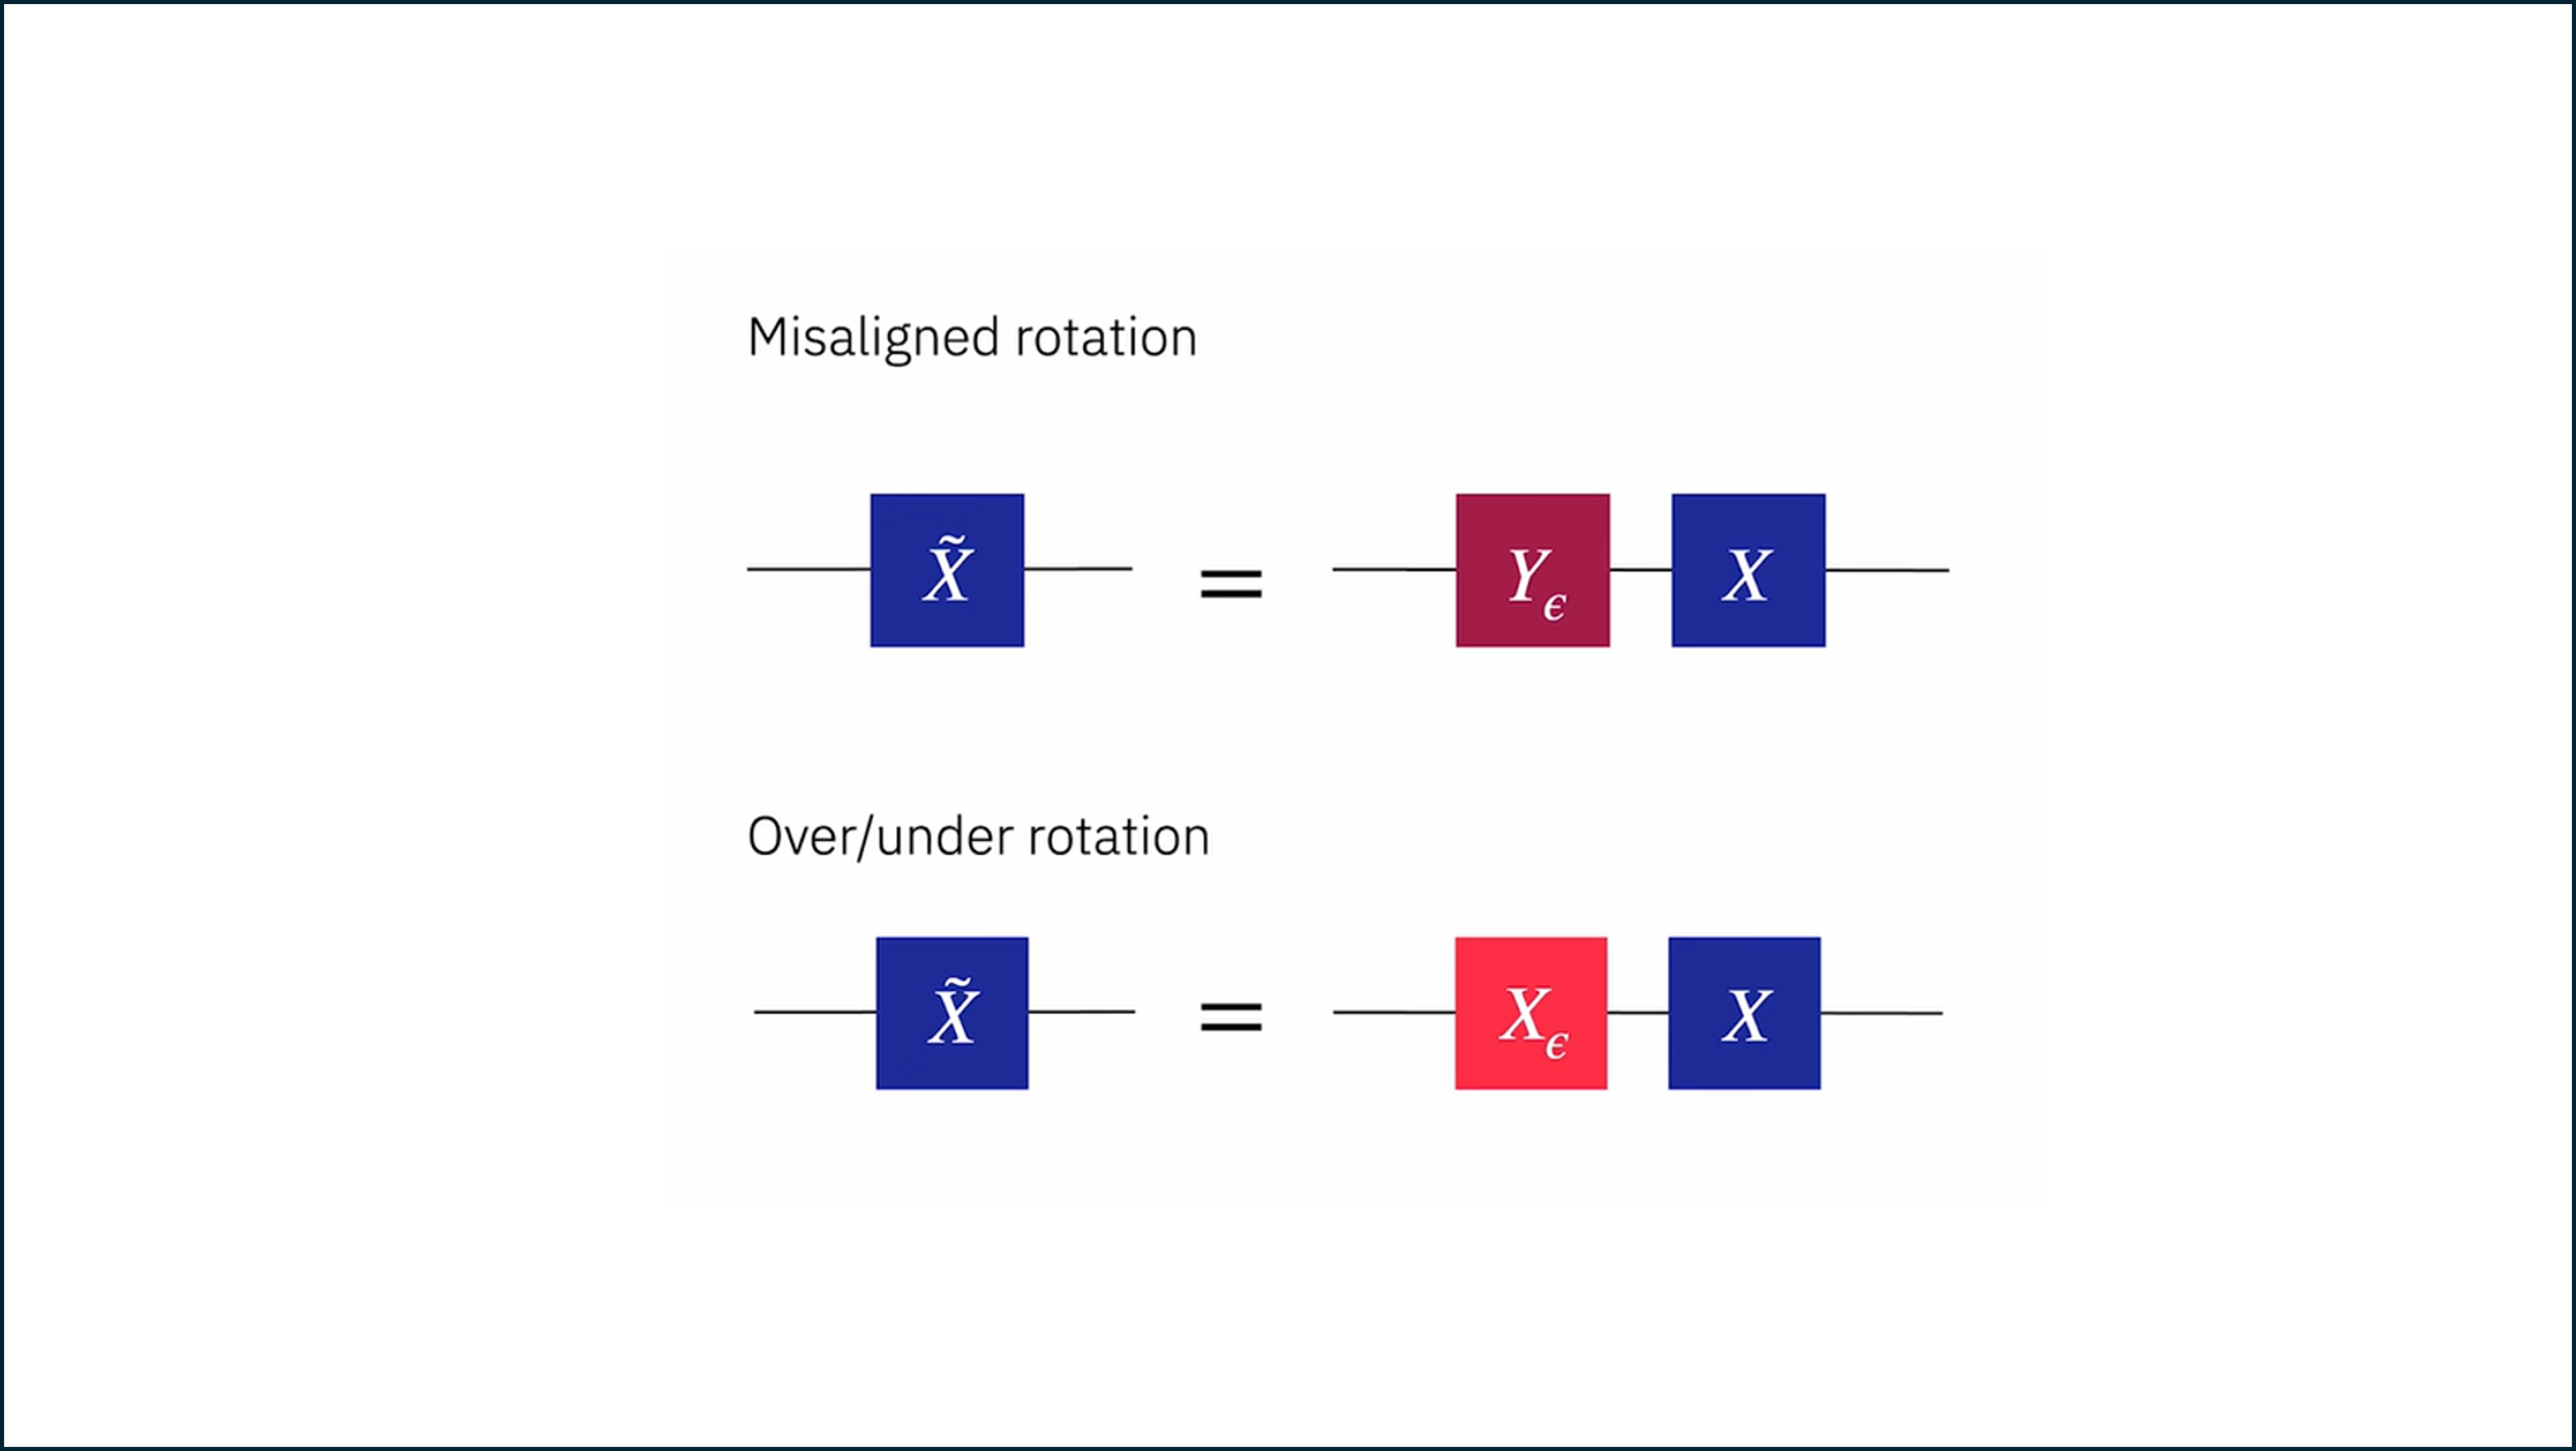

## Two qubit errors and shaded light cones

A single‑qubit gate rotates an isolated qubit. A two‑qubit gate implements logic relying on two qubits, but cannot make a direct measurement of either qubit; it must therefore turn on an interaction between qubits. This interaction is what lets you build entanglement, and it’s also where much of the noise, cross‑talk, and calibration difficulty comes from. This interaction between qubits also allows errors to spread. If one qubit has some error, and it serves as the control qubit for another target qubit, the error can be passed onto the target. In this lesson we will review what two-qubit gates mean for error rates and their spread within a circuit.

### Echoed cross-resonance gates

Different hardware architectures and gate families engineer that interaction in different ways. IBM quantum computers implement abstract two-qubit gates like CZ or CX gates using hardware-native echoed cross resonance (ECR) gates. ECR gates generate an effective $ZX$ interaction using a microwave drive. Related gates like CNOT are built from $ZX$ by adding single‑qubit rotations.

Different qubits have different resonant frequencies (frequencies to which they react strongly). A standard operation might use that resonant frequency to induce a transition in a qubit. But what happens if you drive qubit C at the resonant frequency of an adjacent qubit T? Adjacent qubits are linked by a fixed capacitive or resonator‑mediated interaction. Due to this coupling, a drive on qubit C “leaks through” into the Hamiltonian of qubit T. The strength and direction of this effective drive depend on the state of qubit C ($|0\rangle$ or $|1\rangle$). Here, qubit C is the control and qubit T is the target.

The result is an effective target‑qubit rotation conditioned on the control qubit’s state. Mathematically:
$$
H_{eff} \approx \Omega Z_C X_T +\text{other terms}
$$
This ZX interaction is exactly what you need to build a CNOT. But the other terms might include some errors, and are almost certain to include capacitive coupling between qubits C and T, which corresponds to a ZZ term.


$$
H_\mathrm{CR}
= \underbrace{\Omega \, Z_C X_T}_{\text{desired}}
+ \underbrace{\alpha\, I_C X_T + \beta\, Z_C I_T + \gamma\, I_C Z_T + \delta\, Z_C Z_T + \dots}_{\text{undesired}}.
$$

We can think about these additional terms in the following way:

* IX = target gets unintentionally driven
* ZI = control qubit acquires an unwanted Z rotation
* IZ = target qubit acquires an unwanted Z rotation
* ZZ = static state‑dependent phase shift
* others = small XY, XX, higher‑order interactions


An ECR gate is simply a controlled rotation plus a carefully chosen echo pulse on the control qubit. The echo flips the sign of many unwanted terms while preserving the ZX interaction. This process cancels IX and ZI errors pretty well, and sometimes some higher-order terms.
But echoing cannot cancel the static ZZ coupling because it commutes with the echo pulse.
There are other interactions that will not cancel in this process: some residual nonlinearities and spectator‑qubit effects, leakage and long‑range drive contamination, a few others, but the ZZ term is especially important.

This process often requires drive times that are an order of magnitude longer than single-qubit gates. The combination of longer drive times, persistent ZZ terms in the Hamiltonian, and imperfections in coupling make two-qubit gates the dominant source of gate errors. Note also that if one needs interactions in a circuit between qubits that are not adjacent, the necessary SWAP gates are also obviously two-qubit gates. This is why the standard depth-related metric is: __two-qubit, transpiled depth__. We care mostly about two-qubit gates because they dominate gate error, and we need to look at the transpiled circuits because transpilation will often introduce many additional two-qubit gates in the form of SWAP gates.

#### Check your understanding

Explain why we mostly care about two-qubit transpiled depth. Make sure to consider hardware constraints, and the fact that single-qubit gate depth might be much larger.

<Accordion>
<AccordionItem title="Answer">

Two-qubit gates have much higher error rates than single qubit gates. Single qubit gates are not perfect, so there may be cases in which also considering single-qubit depth is useful. But two-qubit gate depth tends to dominate the error behavior of a circuit. We must consider the transpiled circuit. Modern quantum computers do not have all-to-all qubit connectivity. IBM quantum computers either use a square lattice or a "heavy hex" lattice, meaning qubuts have 2, 3, or 4 nearest neighbors to which they can be directly coupled using a single two-qubit gate. Any entanglement with other, non-adjacent qubits requires moving information around on the quantum computer using two-qubit SWAP gates. Thus, transpilation tends to increase two-qubit gate depth. For highly-entangling circuits, this increase may be very large.

</AccordionItem>
</Accordion>

### Shaded light cones

Assume that a single qubit is well-isolated from all others. An error on that qubit will not cause any errors on any other qubits. But when a qubit interacts with another, errors can propagate. The way errors propagate depends on the way qubits interact. Consider the circuit below. Assume that any qubits adjacent in the circuit diagram are also adjacent in the quantum chip (that is, information will not need to be swapped around to other qubits to facilitate the interactions described).

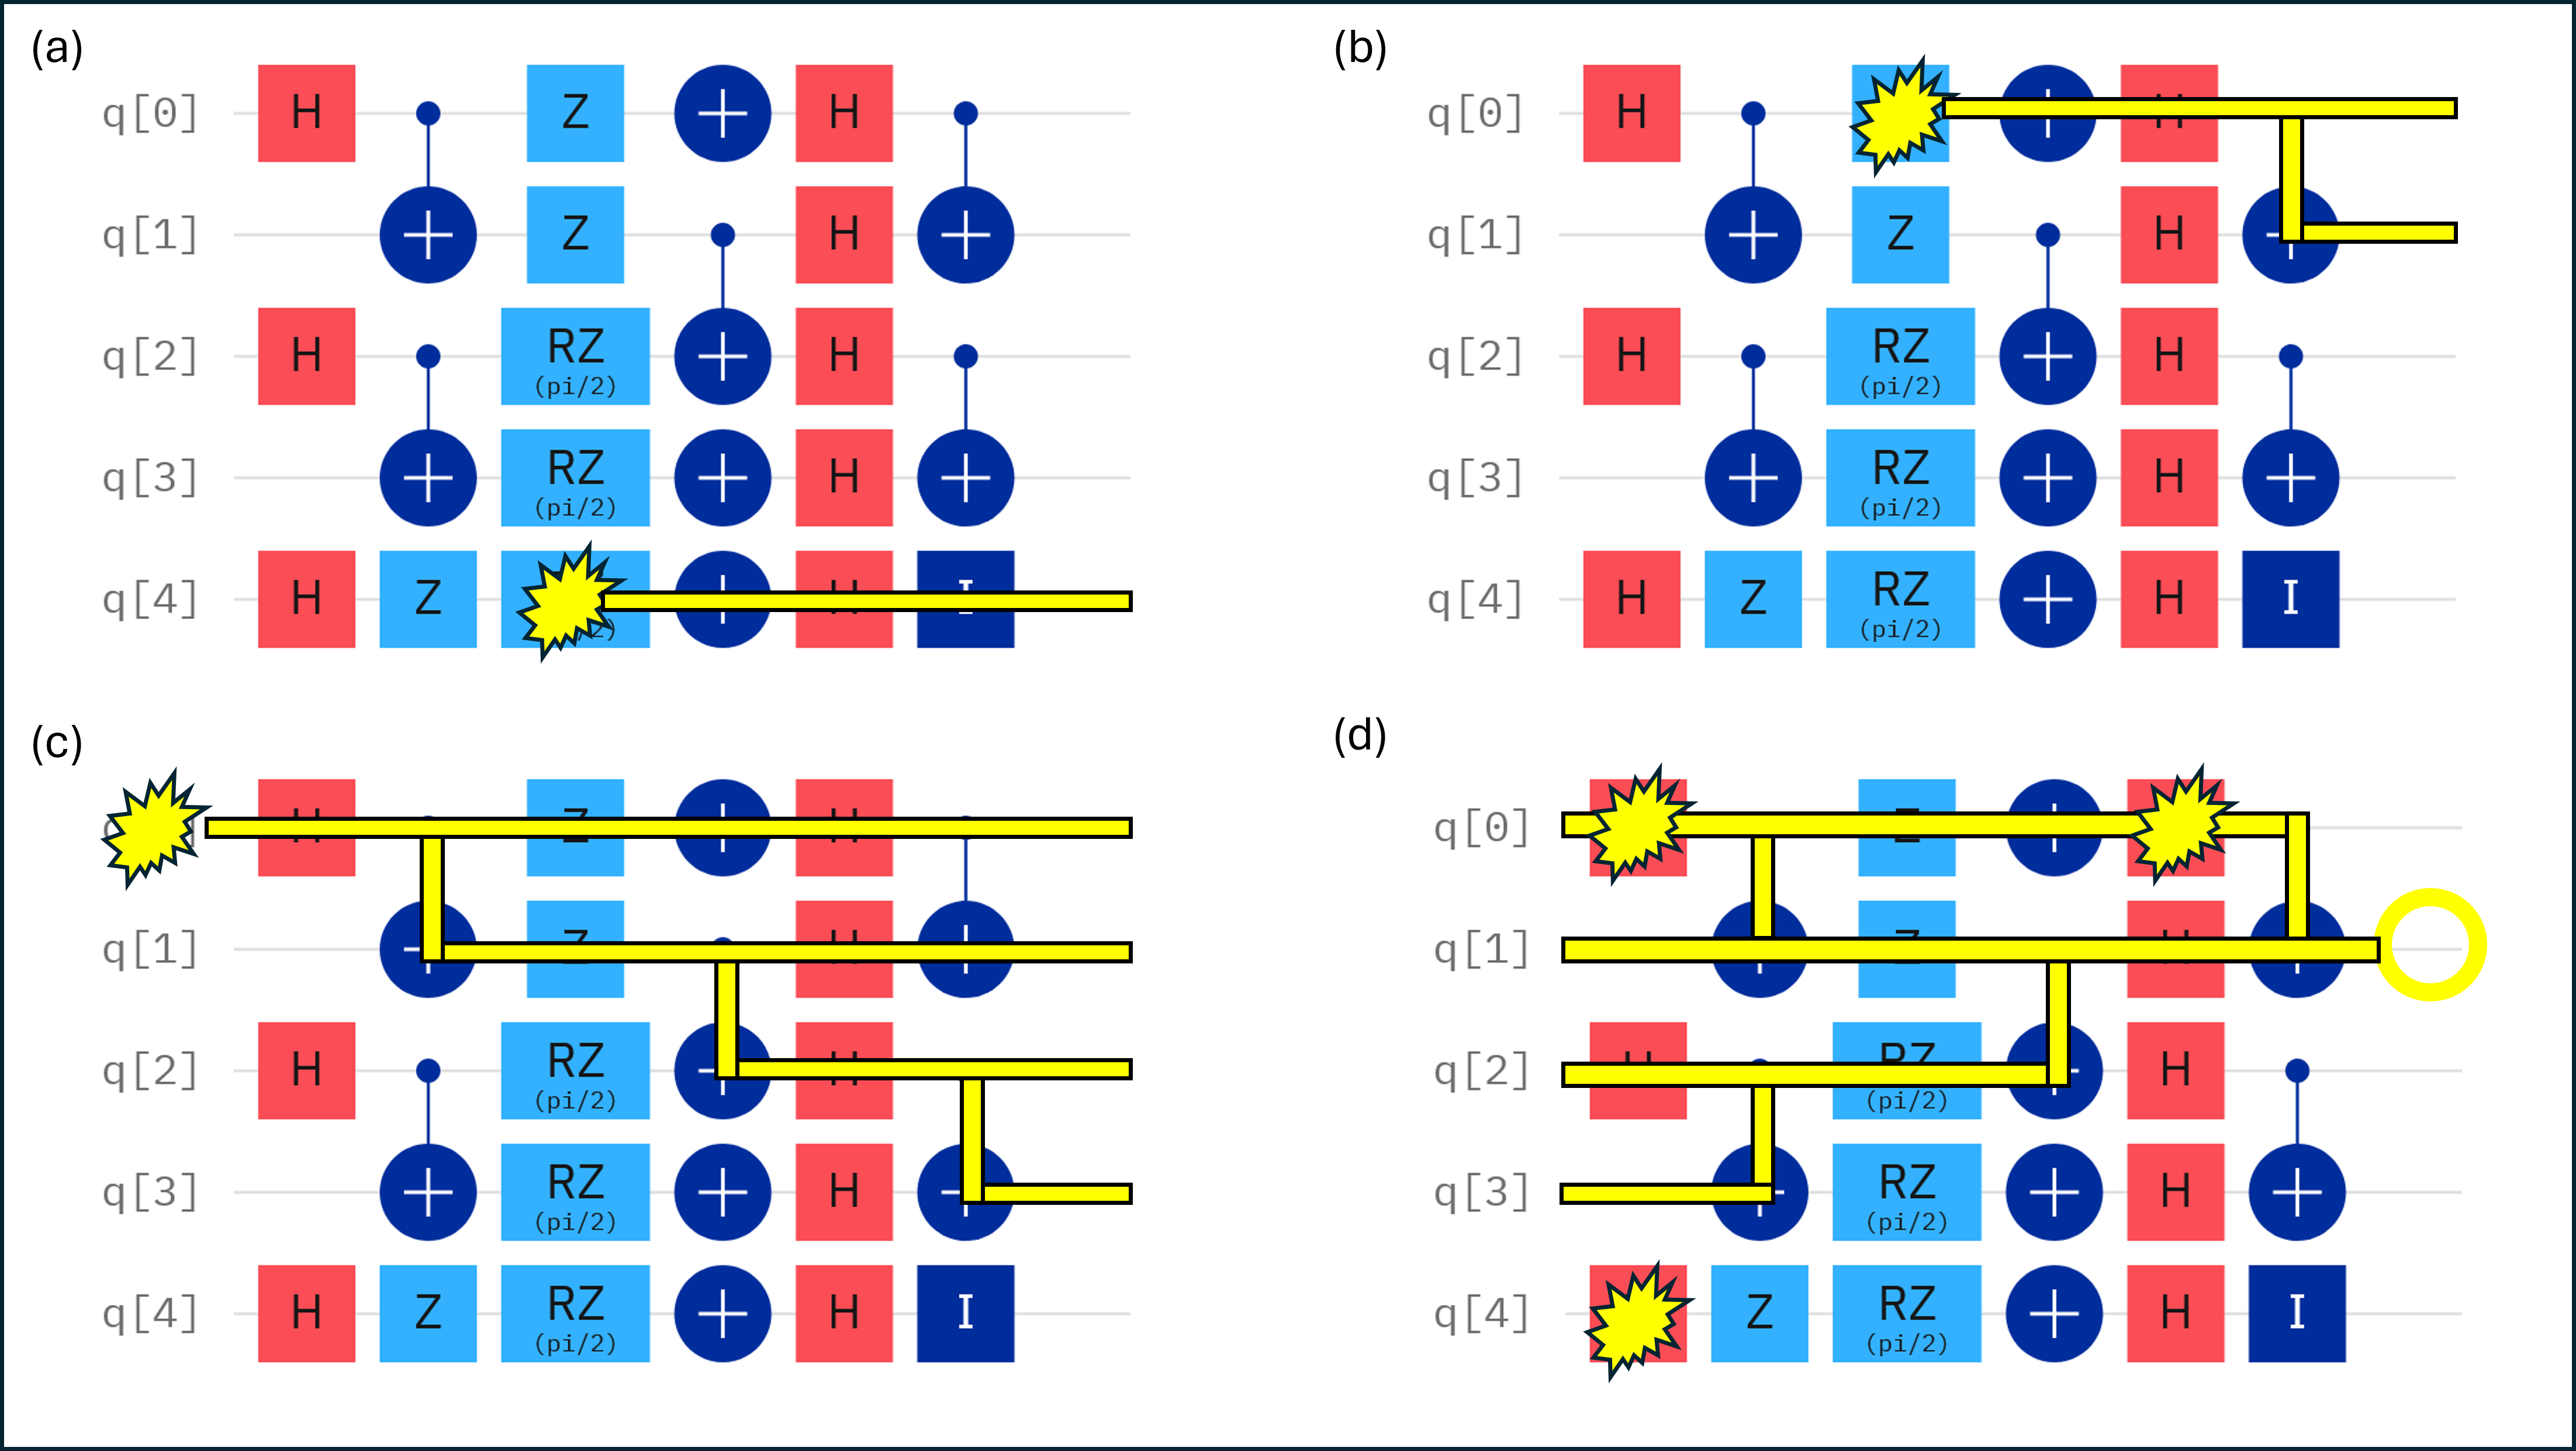

Although you might not have thought of it this way, this is a sort of a spacetime diagram. The vertical axis on a quantum circuit represents different qubits arranged in space. The horizontal axis represents the time over which a sequence of gates are applied. Borrowing language from relativity, a light cone represents the region of spacetime that is reachable from a point via causal interactions.

In the figure above, the type of error has not been specified. It turns out that the type of error affects the light cone since some errors affect the logic of a two-qubit gate, and others do not. We will return to this shortly. For now, consider the yellow lines to be paths of potential spread of some error type. Observe, for example in part (a) of the figure, that a single-qubit error on the RZ gate in qubit 4 can only propagate forward in time on that one qubit. It cannot spread to other qubits because qubit 4 is not entangled with any other qubits. This is a good time to note that qubit 4 is fairly useless in this circuit, and indeed the entire circuit is built for pedagogical purposes only.

An error on the Z gate of qubit 0 (not necessarily a Z-error, just some error at that location), however, could propagate to another qubit: qubit 1, via the final CNOT that uses qubit 0 as the control and qubit 1 as the target. This is shown in part (b). As you might expect, an error earlier in the circuit will often have a chance to propagate across more qubits. Part (c) shows that an error in the initial state preparation of qubit 0 can spread to all qubits except qubit 4, which is isolated.

This setup shows how an error can propagate forward in time to affect measurements. But one can also examine the inverse question: for a specific single-qubit measurement, which parts of my circuit could have contributed some error to it? In that case you would simply start with the measurement or other point of interest and work backwards (in time) through the circuit, following any entangling circuits as shown in part (d). Also shown are a few randomly-chosen points for errors to occur.

In the figure above, errors spread between qubits via ECR gates, but a similar discussion could apply for other two-qubit gates. These gates have a control and a target. It is clear that an error on the control can affect the logic of the gate and can thus result in an error on the target. But what about the other direction? Can an error on the target propagate to the control qubit? Recall that the coupling between control and target for ECR gates is not purely the ideal ZX type; it also has unwanted ZZ coupling.

If an error on the target commutes with the ZZ coupling, then it cannot propagate to the control qubit. One can see this through the physical mechanisms at work. But a quick way to see it is that if an error $E$ commutes with $ZZ$, then their order can be swapped without affecting the outcome. But if $E$ occurring just before the $ZZ$ coupling is the same as it acting after the $ZZ$ coupling, then it cannot affect the control, since in the latter case, the error would have to move backward in time. But if an error does not commute with the ZZ coupling, then it might indeed propagate from the target back to the control. So in the case of an ECR gate, Z errors could not propagate from target to control, but X or Y errors could.

#### Check your understanding

In part (d) of the figure above, look at the vertical lines between qubits 0 and 1. Is it correct that some errors could spread across those lines? Again, it may depend on error type, and we have not discussed this yet. The question is whether any error exists that could propagate as shown by those vertical lines. Explain.

<Accordion>
<AccordionItem title="Answer">

Yes they are correct. In sketching the lightcone backward from the measurement, it might feel like you are claiming that something is moving from the target to the control. However, the meaning of the diagram is actually that an error could have moved from the control (qubit 0) to the target (qubit 1) to cause an error at the point of interest. If your intuition is that it depends on the error type, you are absolutely correct. This is partially addressed in the next section.

</AccordionItem>
</Accordion>



Starting with an error free version of the circuits in the diagram above, trace the potential spread of an error in the first Hadamard gate acting on qubit 2. List all the qubits that could be affected by the end of the circuit if the error is (a) a phase flip, and (b) a bit flip. Hint: think about how information on each qubit is being used.

<Accordion>
<AccordionItem title="Answer">

(a) Qubit 3 could be affected, as well as obviously qubit 2 itself. No others! If you listed qubits 0 and 1, note that qubit 2 is the target of the ECR entangling it with qubit 1. No change is made to qubit 1 in that gate. (b) qubits 0-3 could be affected. The bit flip or X-type error does not commute with the ZZ coupling in the ECR gate and thus can propagate from the target to the control.

</AccordionItem>
</Accordion>

#### Error propagation

In the previous section we discuss error propagation without giving it a formal definition. Going forward:

For an error $E$ that occurs before some part of the logical payload of a circuit $U$, error propagation means finding the equivalent operator $E'$' that reproduces the same faulty outcome when applied after $U$ instead of before it.

$$
\boxed{
\text{An error } E \text{ propagates through a unitary } U \text{ as } E' = U E U^\dagger
}
$$

$$
\boxed{
U\,E\,|\psi\rangle = E'\,U\,|\psi\rangle
}
$$

The image of error propagation in the previous section suggested that errors could spread from a control qubit to a target qubit across a CNOT gate. One way to check when this is true is to consider an error on the control or on the target prior to entanglement, and check whether that operator commutes with the CNOT gate. If the two operators commute, then there is no difference if you apply them in the reverse order, meaning the error could be simply "moved past" the CNOT without having any effect on other qubits. This is the most common way people approach error propagation, and it yields the following rules:

Let control be qubit 0 and target be qubit 1. And consider X and Z errors on the control and target qubits ($X_c$, $Z_c$, $X_t$, and $Z_t$, respectively). Moving these errors past a $\text{CNOT}_{0\to1}$ causes the errors to become:

$$
\begin{aligned}
X_c &\to X_c X_t​\\
Z_c &\to Z_c​\\
X_t &\to X_t\\
Z_t &\to Z_c Z_t
\end{aligned}
$$

We state the above without proof. But if you are like the author of this lesson, and prefer the Schroedinger picture, you can also write down arbitrary control and target states, apply the error, then the CNOT, and examine the final state. Comparing that final state to an error free case allows you to see what error combination applied after the CNOT would yield the erroneous state, and in particular, you can see if the error operation has spread from one qubit to the other.

| Control initial | Target initial | Error | Final | Post-CNOT error equiv. |
|---------------|-------------|------------|----------|--------|
| $\alpha\vert 0\rangle+\beta \vert 1\rangle$ | $\gamma \vert 0\rangle+\delta \vert 1\rangle$ | None           | $\alpha\gamma \vert 00\rangle+\alpha\delta \vert 10\rangle + \beta\gamma  \vert 11\rangle +\beta\delta  \vert 01\rangle$ | Not applicable |
| $\alpha\vert 0\rangle+\beta \vert 1\rangle$ | $\gamma \vert 0\rangle+\delta \vert 1\rangle$ | X on control   | $\alpha\gamma \vert 11\rangle+\alpha\delta \vert 01\rangle + \beta\gamma  \vert 10\rangle +\beta\delta  \vert 00\rangle$ | $X_c X_t$ |
| $\alpha\vert 0\rangle+\beta \vert 1\rangle$ | $\gamma \vert 0\rangle+\delta \vert 1\rangle$ | Z on control   | $\alpha\gamma \vert 00\rangle+\alpha\delta \vert 10\rangle - \beta\gamma  \vert 11\rangle -\beta\delta  \vert 01\rangle$ | $Z_c$ |
| $\alpha\vert 0\rangle+\beta \vert 1\rangle$ | $\gamma \vert 0\rangle+\delta \vert 1\rangle$ | X on target    | $\alpha\gamma \vert 10\rangle+\alpha\delta \vert 00\rangle + \beta\gamma  \vert 01\rangle +\beta\delta  \vert 11\rangle$ | $X_t$ |
| $\alpha\vert 0\rangle+\beta \vert 1\rangle$ | $\gamma \vert 0\rangle+\delta \vert 1\rangle$ | Z on target    | $\alpha\gamma \vert 00\rangle-\alpha\delta \vert 10\rangle + \beta\gamma  \vert 11\rangle -\beta\delta  \vert 01\rangle$ | $Z_c Z_t$ |

Perhaps surprisingly, a Z error on the target does cause an error to be propagated back to the control!

As you can imagine, tracking such propagation of error operators forward through circuits (or equivalently, propagating backward the operators to be measured) is complicated. Qiskit has tools to facilitate this, which we learn about in lesson 6 on modern workflows.

There is a Qiskit addon called [Shaded Lightcones](https://qiskit.github.io/qiskit-addon-slc/). The shaded lightcones (SLC) addon analyzes error propagation in quantum circuits using Pauli propagation to identify which parts of a circuit can actually influence a target observable. It is designed primarily to make error mitigation more efficient, especially for probabilistic error cancellation (PEC) workflows. We will only briefly explore this tool here, and make wider use of it in the context of error mitigation techniques in future lessons. It uses Pauli operator propagation to map out propagation of errors of different types, producing a light cone for X, Y, and Z type errors.

Shaded lightcones (SLC) go further, using classical simulations to more tightly bound the sensitivity to errors throughout the circuit. This trades some QPU time for CPU time and reduces the sampling overhead needed to renormalize the bias. Instead of a hard cutoff, each potential error in the circuit is assigned a graded “shade” that upper-bounds the susceptibility of the observable to that error. This refined characterization allows for more efficient, targeted applications of PEC with reduced variance, while giving the user the ability to controllably tune the bias in the observable estimation. See [Lightcone shading for classically accelerated quantum error mitigation](https://arxiv.org/abs/2409.04401) for more details.

We will not present a full workflow here. We simply show diagrammatically, how this workflow takes a circuit:

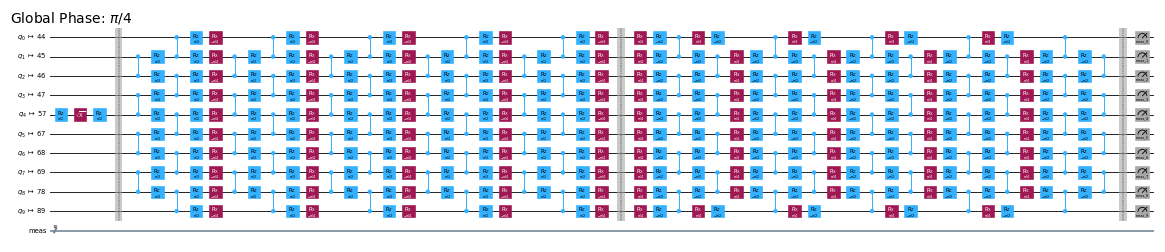

Separates it into "boxes" useful for learning noise behavior:

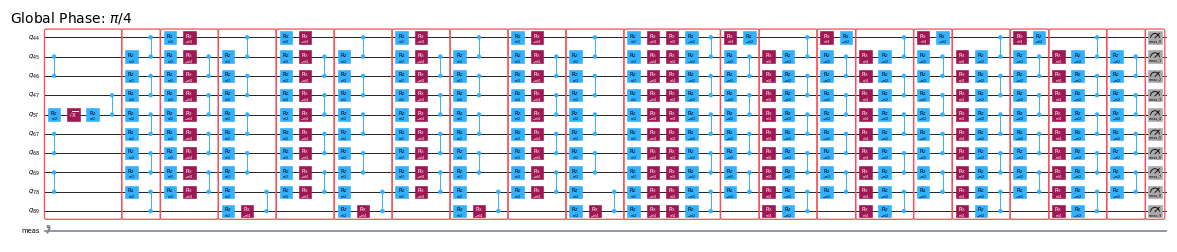

And finally uses operator propagation and noise learning to produce a shaded map of error susceptibility throughout the circuit:

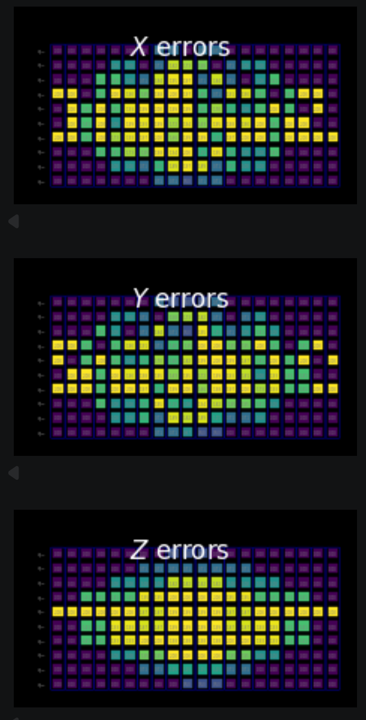

Each colored box in the output corresponds to a specific qubit at a specific time. The darkest (purple) boxes indicate a qubit and layer at which an error cannot propagate to the measurement(s) of interest. The brightest (yellow) boxes correspond to a qubit and layer at which an error can have a strong influence on the measurement(s) of interest.

Note the purple regions on the right of each map. An error at the same layer as the measurement, but on a different qubit, cannot affect the measurement through the circuit connectivity shown. Similarly, an error one layer back in time (one layer to the left) can only propagate to the adjacent qubit in the next step, because of the structure of the entangling layer, and so on. So the cone shape on the right is general whenever relatively few qubits are involved in the measurement of interest.

#### Check your understanding

Do you think it is better to make a shaded lightcone map before or after transpilation? Why?

<Accordion>
<AccordionItem title="Answer">

It must be done after transpilation. In order for these different maps to be useful we must make sure that the adjacent qubits in our circuit corresponded to adjacent qubits on our quantum chip. Otherwise, entangling gates shown as acting on the adjacent qubits in the circuit diagram would end up requiring SWAP gates and more complicated circuit structure.

</AccordionItem>
</Accordion>